#PROJETO A SAFRA ANTES DA COLHEITA: DA PARA PREVER A PRODUTIVIDADE DA SOJA SÓ COM DADOS PUBLICOS?

In [28]:
#Importando bibliotecas
import sidrapy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import theilslopes
import geobr
import geopandas as gpd
from matplotlib.patches import Patch




#Importando a tabela 5457 do SIDRA (SITE IBGE) com os dados de produção de soja no estado de São Paulo nos últimos 12 anos
dados_soja = sidrapy.get_table(
    table_code="5457",
    territorial_level="6",
    ibge_territorial_code="in n3 35",
    variable="112,216",
    classifications= {"782": "40124"},
    period="last 12"
)

In [29]:
#Verificar colunas do dataframe
dados_soja.columns

Index(['NC', 'NN', 'MC', 'MN', 'V', 'D1C', 'D1N', 'D2C', 'D2N', 'D3C', 'D3N',
       'D4C', 'D4N'],
      dtype='str')

In [30]:
#Verificando o dataframe
dados_soja.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Município,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias e permanentes...,Produto das lavouras temporárias e permanentes
1,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2014,2014,112,Rendimento médio da produção,40124,Soja (em grão)
2,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2014,2014,216,Área colhida,40124,Soja (em grão)
3,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2015,2015,112,Rendimento médio da produção,40124,Soja (em grão)
4,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2015,2015,216,Área colhida,40124,Soja (em grão)


In [31]:
#Mostrando as ultimas linhas do dataframe
dados_soja.tail()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
15404,6,Município,1006,Hectares,400,3557303,Estiva Gerbi - SP,2023,2023,216,Área colhida,40124,Soja (em grão)
15405,6,Município,33,Quilogramas por Hectare,3900,3557303,Estiva Gerbi - SP,2024,2024,112,Rendimento médio da produção,40124,Soja (em grão)
15406,6,Município,1006,Hectares,500,3557303,Estiva Gerbi - SP,2024,2024,216,Área colhida,40124,Soja (em grão)
15407,6,Município,33,Quilogramas por Hectare,3900,3557303,Estiva Gerbi - SP,2025,2025,112,Rendimento médio da produção,40124,Soja (em grão)
15408,6,Município,1006,Hectares,520,3557303,Estiva Gerbi - SP,2025,2025,216,Área colhida,40124,Soja (em grão)


In [32]:
#Verificando os dados gerais do dataframe
dados_soja.info()

<class 'pandas.DataFrame'>
RangeIndex: 15409 entries, 0 to 15408
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NC      15409 non-null  str  
 1   NN      15409 non-null  str  
 2   MC      15409 non-null  str  
 3   MN      15409 non-null  str  
 4   V       15409 non-null  str  
 5   D1C     15409 non-null  str  
 6   D1N     15409 non-null  str  
 7   D2C     15409 non-null  str  
 8   D2N     15409 non-null  str  
 9   D3C     15409 non-null  str  
 10  D3N     15409 non-null  str  
 11  D4C     15409 non-null  str  
 12  D4N     15409 non-null  str  
dtypes: str(13)
memory usage: 3.1 MB


In [33]:
#Renomeando as colunas do dataframe para facilitar a manipulação dos dados
dados_soja.rename(columns={"NC": "Nível Territorial (Código)", "NN": "Nível Territorial (Nome)", "MC": "Unidade de Medida (Código)", "MN": "Unidade de Medida (Nome)", "V": "Valor", "D1C": "Municipio (Código)", "D1N": "Municipio", "D2C": "Ano Codigo", "D2N": "Ano", "D3C": "Variavel Codigo", "D3N": "Variavel", "D4N": "Cultura"}, inplace=True)

#Excluindo a primeira linha da planilha
dados_soja = dados_soja.drop(0)

dados_soja.head()

,Nível Territorial (Código),Nível Territorial (Nome),Unidade de Medida (Código),Unidade de Medida (Nome),Valor,Municipio (Código),Municipio,Ano Codigo,Ano,Variavel Codigo,Variavel,D4C,Cultura
1,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2014,2014,112,Rendimento médio da produção,40124,Soja (em grão)
2,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2014,2014,216,Área colhida,40124,Soja (em grão)
3,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2015,2015,112,Rendimento médio da produção,40124,Soja (em grão)
4,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2015,2015,216,Área colhida,40124,Soja (em grão)
5,6,Município,33,Quilogramas por Hectare,1800,3500105,Adamantina - SP,2016,2016,112,Rendimento médio da produção,40124,Soja (em grão)


In [34]:
#Verificando e excluindo duplicados
dados_soja.duplicated().sum()


np.int64(0)

In [35]:
#Alterando valores nulos para 0
dados_soja = dados_soja.fillna(0)

In [36]:
#Converter valores e colocar as variaves lado a lado

base_soja = dados_soja.copy()

base_soja["Valor"] = pd.to_numeric(base_soja["Valor"], errors="coerce")
base_soja["Ano"] = base_soja["Ano"].astype(int)
base_soja["Variavel Codigo"] = base_soja["Variavel Codigo"].astype(str)


#Uma linha por municipio-ano, com rendimento (112) e area colhida (216)

base = (
    base_soja.pivot_table(
        index=["Municipio (Código)","Municipio","Ano"],
        columns="Variavel Codigo",
        values="Valor",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"112": "rendimento_kg_ha", "216": "area_colhida_ha"})

)

base.columns.name = None

#Mantem só municipio e ano que efetivamente colheu soja

base = base[(base["rendimento_kg_ha"] > 0) & (base["area_colhida_ha"] > 0)].copy()


In [37]:
#Produtividade estadual por ano(ponderada pela área colhida)

# Média simples trataria um município de 50 ha igual a um de 50.000 ha.
# A média ponderada pela área = produção total / área total (visão do estado).

base["producao_total_kg"] = base["rendimento_kg_ha"] * base["area_colhida_ha"]

estadual = base.groupby("Ano").agg(
    area_colhida_ha=("area_colhida_ha", "sum"),
    producao_total_kg=("producao_total_kg", "sum"),
    rend_media_simples_kg_ha=("rendimento_kg_ha", "mean"),
    n_municipios=("Municipio (Código)", "nunique"),
)

estadual["rend_kg_ha"] = estadual["producao_total_kg"] / estadual["area_colhida_ha"]
estadual["rend_sc_ha"] = estadual["rend_kg_ha"] / 60

In [38]:
#Ganho Tecnológico:tendencia robusta (Theil-Sen) da produtividade estadual (kg/ha) ao longo do tempo

anos = estadual.index.values
y = estadual["rend_kg_ha"].values

slope, intercept, slope_lo, slope_hi = theilslopes(y, anos, 0.95)
slope_ols, intercept_ols = np.polyfit(anos, y, 1)  #para comparar

estadual["tendencia_kg_ha"] = intercept + slope * anos
estadual["tendencia_sc_ha"] = estadual["tendencia_kg_ha"] / 60

ganho_pct_ano = slope/ estadual["tendencia_kg_ha"].mean() * 100


In [39]:
#Anos de quebra: desvio em relação à tendencia

LIMIAR_QUEBRA_PCT = -10   # ano X% abaixo da tendência = quebra (ajustável)
LIMIAR_Z = -1.5           # ou desvio robusto muito abaixo do normal
 
estadual["residuo_kg_ha"] = y - estadual["tendencia_kg_ha"]
estadual["desvio_pct"] = (y / estadual["tendencia_kg_ha"] - 1) * 100
 
# Desvio-padrão robusto dos resíduos (MAD), menos sensível às próprias quebras
res = estadual["residuo_kg_ha"]
sigma_robusto = 1.4826 * np.median(np.abs(res - np.median(res)))
estadual["z_robusto"] = res / sigma_robusto if sigma_robusto > 0 else 0.0
 
estadual["quebra"] = (estadual["desvio_pct"] <= LIMIAR_QUEBRA_PCT) | (
    estadual["z_robusto"] <= LIMIAR_Z
)

In [40]:
# Resumo
print("=" * 70)
print("PRODUTIVIDADE DE SOJA — ESTADO DE SÃO PAULO")
print("=" * 70)
print(f"Período: {anos.min()}–{anos.max()}")
print(
    f"Ganho tecnológico (Theil-Sen): {slope:+.1f} kg/ha/ano "
    f"({slope / 60:+.2f} sc/ha/ano | {ganho_pct_ano:+.2f}% ao ano)"
)
print(
    f"IC 95% da inclinação: {slope_lo:+.1f} a {slope_hi:+.1f} kg/ha/ano"
)
print(f"Comparação — regressão linear (OLS): {slope_ols:+.1f} kg/ha/ano")
print(f"Anos de quebra: {list(estadual.index[estadual['quebra']]) or 'nenhum'}")
print()
 
tabela = estadual[
    ["n_municipios", "area_colhida_ha", "rend_kg_ha", "rend_sc_ha",
     "tendencia_sc_ha", "desvio_pct", "z_robusto", "quebra"]
].round(2)
display(tabela) if "display" in dir(__builtins__) or "get_ipython" in globals() else print(tabela)
 


PRODUTIVIDADE DE SOJA — ESTADO DE SÃO PAULO
Período: 2014–2025
Ganho tecnológico (Theil-Sen): +40.0 kg/ha/ano (+0.67 sc/ha/ano | +1.16% ao ano)
IC 95% da inclinação: -5.2 a +107.2 kg/ha/ano
Comparação — regressão linear (OLS): +37.0 kg/ha/ano
Anos de quebra: [2014, 2024]



,n_municipios,area_colhida_ha,rend_kg_ha,rend_sc_ha,tendencia_sc_ha,desvio_pct,z_robusto,quebra
Ano,,,,,,,,
2014,300,692589.0,2467.89,41.13,53.58,-23.24,-3.34,True
2015,320,791903.0,3038.53,50.64,54.25,-6.65,-0.97,False
2016,364,848782.0,3290.32,54.84,54.91,-0.14,-0.02,False
2017,395,946540.0,3477.78,57.96,55.58,4.29,0.64,False
2018,405,973064.0,3504.72,58.41,56.25,3.85,0.58,False
2019,432,1080336.0,3198.56,53.31,56.91,-6.33,-0.97,False
2020,441,1132955.0,3431.30,57.19,57.58,-0.68,-0.11,False
2021,464,1199351.0,3489.20,58.15,58.25,-0.16,-0.03,False
2022,470,1252070.0,3576.50,59.61,58.91,1.18,0.19,False


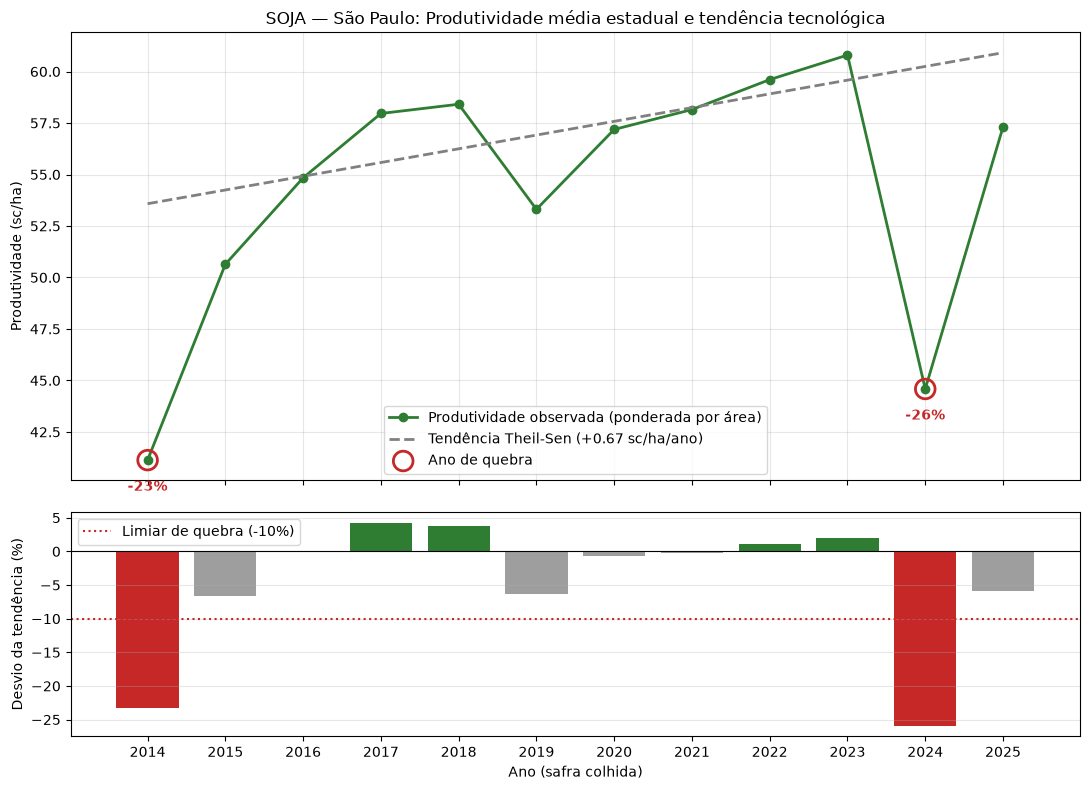

In [41]:
#Gráficos

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
 
# 6.1 Produtividade observada x tendência
ax1.plot(anos, estadual["rend_sc_ha"], "o-", color="#2E7D32", lw=2,
         label="Produtividade observada (ponderada por área)")
ax1.plot(anos, estadual["tendencia_sc_ha"], "--", color="gray", lw=2,
         label=f"Tendência Theil-Sen ({slope / 60:+.2f} sc/ha/ano)")
 
q = estadual[estadual["quebra"]]
ax1.scatter(q.index, q["rend_sc_ha"], s=200, facecolors="none",
            edgecolors="#C62828", linewidths=2, zorder=5, label="Ano de quebra")
for ano, row in q.iterrows():
    ax1.annotate(f"{row['desvio_pct']:.0f}%", (ano, row["rend_sc_ha"]),
                 textcoords="offset points", xytext=(0, -22), ha="center",
                 color="#C62828", fontweight="bold")
 
ax1.set_ylabel("Produtividade (sc/ha)")
ax1.set_title("SOJA — São Paulo: Produtividade média estadual e tendência tecnológica")
ax1.legend(loc="best")
ax1.grid(alpha=0.3)
 
# 6.2 Desvio em relação à tendência
cores = np.where(estadual["quebra"], "#C62828",
                 np.where(estadual["desvio_pct"] >= 0, "#2E7D32", "#9E9E9E"))
ax2.bar(anos, estadual["desvio_pct"], color=cores)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(LIMIAR_QUEBRA_PCT, color="#C62828", ls=":",
            label=f"Limiar de quebra ({LIMIAR_QUEBRA_PCT}%)")
ax2.set_ylabel("Desvio da tendência (%)")
ax2.set_xlabel("Ano (safra colhida)")
ax2.set_xticks(anos)
ax2.legend(loc="best")
ax2.grid(alpha=0.3, axis="y")
 
plt.tight_layout()
plt.show()
 

In [42]:
#Realizar o mapa de produtividade média por periodo, com malha do geobr
# Média ponderada pela área (produção total / área total do período):
# um ano com 20 ha colhidos não pesa igual a um ano com 5.000 ha.


MIN_ANOS = 3  # municípios com menos anos de colheita = média pouco confiável

prod_mun = (
    base.groupby(["Municipio (Código)", "Municipio"])
    .agg(
        producao_total_kg=("producao_total_kg", "sum"),
        area_total_ha=("area_colhida_ha", "sum"),
        area_media_ha=("area_colhida_ha", "mean"),
        n_anos=("Ano", "nunique"),
        rend_min_kg_ha=("rendimento_kg_ha", "min"),
        rend_max_kg_ha=("rendimento_kg_ha", "max"),
        rend_std_kg_ha=("rendimento_kg_ha", "std"),
    )
    .reset_index()
)
prod_mun["rend_medio_kg_ha"] = prod_mun["producao_total_kg"] / prod_mun["area_total_ha"]
prod_mun["rend_medio_sc_ha"] = prod_mun["rend_medio_kg_ha"] / 60
prod_mun["cv_pct"] = prod_mun["rend_std_kg_ha"] / prod_mun["rend_medio_kg_ha"] * 100
prod_mun["confiavel"] = prod_mun["n_anos"] >= MIN_ANOS
prod_mun["cod_muni"] = prod_mun["Municipio (Código)"].astype(int)

In [43]:
#Malha municipal de SP (geobr / IBGE)

mun_sp = geobr.read_municipality(code_muni="SP", year=2020)
mun_sp["cod_muni"] = mun_sp["code_muni"].astype(int)

In [44]:
#Verificando junção SIDRA x geobr

cod_sidra = set(prod_mun["cod_muni"])
cod_malha = set(mun_sp["cod_muni"])
sem_malha = cod_sidra - cod_malha
 
print("=" * 70)
print("VERIFICAÇÃO DA JUNÇÃO SIDRA x GEOBR")
print("=" * 70)
print(f"Municípios na malha de SP (geobr):          {len(cod_malha)}")
print(f"Municípios com soja no período (SIDRA):     {len(cod_sidra)}")
print(f"  - com >= {MIN_ANOS} anos de colheita:           {prod_mun['confiavel'].sum()}")
print(f"  - com <  {MIN_ANOS} anos (baixa confiança):     {(~prod_mun['confiavel']).sum()}")
print(f"Municípios sem soja no período:             {len(cod_malha - cod_sidra)}")
print(f"Códigos do SIDRA sem correspondência na malha: {len(sem_malha)}")
if sem_malha:
    print(prod_mun[prod_mun["cod_muni"].isin(sem_malha)][["cod_muni", "Municipio"]])
 
mapa = mun_sp.merge(prod_mun, on="cod_muni", how="left")
 

VERIFICAÇÃO DA JUNÇÃO SIDRA x GEOBR
Municípios na malha de SP (geobr):          645
Municípios com soja no período (SIDRA):     514
  - com >= 3 anos de colheita:           489
  - com <  3 anos (baixa confiança):     25
Municípios sem soja no período:             131
Códigos do SIDRA sem correspondência na malha: 0


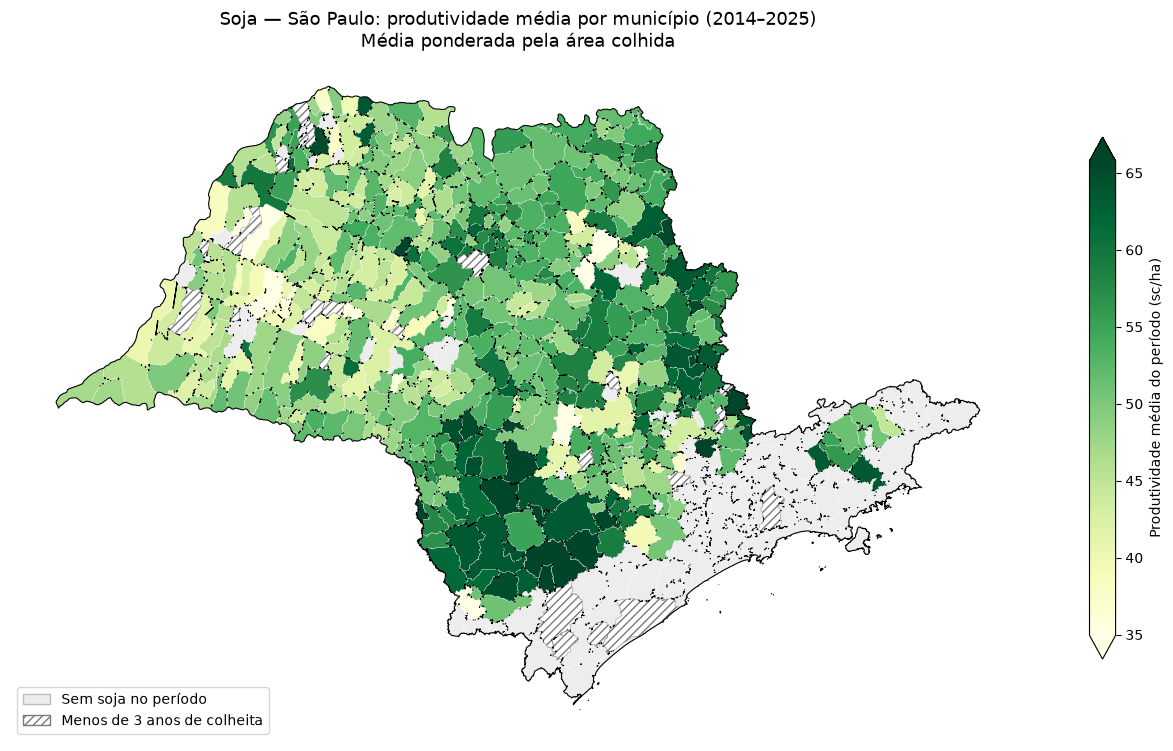

In [45]:
#Mapa

com_soja = mapa[mapa["confiavel"] == True]
pouca_serie = mapa[mapa["confiavel"] == False]
sem_soja = mapa[mapa["rend_medio_sc_ha"].isna()]
 
# Escala cortada nos percentis 2–98 para outliers não "lavarem" as cores
vmin, vmax = np.nanpercentile(com_soja["rend_medio_sc_ha"], [2, 98])
 
fig, ax = plt.subplots(figsize=(13, 9))
 
sem_soja.plot(ax=ax, color="#EDEDED", edgecolor="white", linewidth=0.2)
com_soja.plot(
    ax=ax, column="rend_medio_sc_ha", cmap="YlGn", vmin=vmin, vmax=vmax,
    edgecolor="white", linewidth=0.2, legend=True,
    legend_kwds={"label": "Produtividade média do período (sc/ha)", "shrink": 0.6},
)
if len(pouca_serie):
    pouca_serie.plot(ax=ax, facecolor="none", edgecolor="#7A7A7A",
                     hatch="////", linewidth=0.3)
mun_sp.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8)
 
anos_periodo = f"{base['Ano'].min()}–{base['Ano'].max()}"
ax.set_title(f"Soja — São Paulo: produtividade média por município ({anos_periodo})\n"
             "Média ponderada pela área colhida", fontsize=13)
ax.legend(
    handles=[
        Patch(facecolor="#EDEDED", edgecolor="#BDBDBD", label="Sem soja no período"),
        Patch(facecolor="white", edgecolor="#7A7A7A", hatch="////",
              label=f"Menos de {MIN_ANOS} anos de colheita"),
    ],
    loc="lower left", frameon=True,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()
 

In [46]:
# 5. Destaques (apenas municípios com série confiável)
# ---------------------------------------------------------------------------
cols = ["Municipio", "n_anos", "area_media_ha", "rend_medio_sc_ha", "cv_pct"]
ranking = prod_mun[prod_mun["confiavel"]].sort_values("rend_medio_sc_ha", ascending=False)
 
print("\nTOP 10 — maior produtividade média")
print(ranking[cols].head(10).round(1).to_string(index=False))
print("\nTOP 10 — menor produtividade média")
print(ranking[cols].tail(10).round(1).to_string(index=False))
print("\nTOP 10 — maior área média colhida (principais produtores)")
print(ranking.sort_values("area_media_ha", ascending=False)[cols].head(10)
      .round(1).to_string(index=False))



TOP 10 — maior produtividade média
                   Municipio  n_anos  area_media_ha  rend_medio_sc_ha  cv_pct
           Capão Bonito - SP      12        20875.0              74.2    10.1
        Ribeirão Grande - SP      11         1709.1              72.7     9.0
     São Miguel Arcanjo - SP      12         8450.0              72.6    16.7
                Ubarana - SP      12          300.0              70.8    22.8
                Itatiba - SP       9          130.0              69.7    11.5
               Itatinga - SP      12          975.8              69.3    10.4
               Pratânia - SP       8          193.0              68.5     8.9
Campina do Monte Alegre - SP      12         4000.0              66.5    13.3
      Barão de Antonina - SP      12         2516.7              66.4    13.1
                Socorro - SP      11          877.3              66.3     7.6

TOP 10 — menor produtividade média
                   Municipio  n_anos  area_media_ha  rend_medio_sc_ha 

## Variabilidade: coeficiente de variação por município (estáveis x arriscados)

In [47]:
MIN_ANOS_CV = 8          # mínimo de safras com colheita para entrar na análise
LIMIAR_REPETICAO = 0.5   # >= 50% dos anos com rendimento idêntico ao ano anterior = série suspeita

ano_ref = estadual.index.max()
fator_tec = estadual.loc[ano_ref, "tendencia_kg_ha"] / estadual["tendencia_kg_ha"]
base["rend_ajust_kg_ha"] = base["rendimento_kg_ha"] * base["Ano"].map(fator_tec)

# Valores repetidos ano a ano: na PAM/IBGE alguns municípios repetem a estimativa,
# o que gera CV artificialmente baixo (parece estável, mas é falta de informação)
base = base.sort_values(["Municipio (Código)", "Ano"])
base["rend_repetido"] = base.groupby("Municipio (Código)")["rendimento_kg_ha"].diff().eq(0)

var_mun = (
    base.groupby(["Municipio (Código)", "Municipio"])
    .agg(
        n_anos=("Ano", "nunique"),
        area_media_ha=("area_colhida_ha", "mean"),
        rend_medio_kg_ha=("rend_ajust_kg_ha", "mean"),
        std_kg_ha=("rend_ajust_kg_ha", "std"),
        pior_ano_kg_ha=("rend_ajust_kg_ha", "min"),
        rend_bruto_medio=("rendimento_kg_ha", "mean"),
        std_bruto=("rendimento_kg_ha", "std"),
        n_repetidos=("rend_repetido", "sum"),
    )
    .reset_index()
)

# Média simples aqui (cada safra pesa igual): o CV mede a oscilação ano a ano do município
var_mun["cv_pct"] = var_mun["std_kg_ha"] / var_mun["rend_medio_kg_ha"] * 100
var_mun["cv_bruto_pct"] = var_mun["std_bruto"] / var_mun["rend_bruto_medio"] * 100
var_mun["rend_medio_sc_ha"] = var_mun["rend_medio_kg_ha"] / 60
var_mun["queda_pior_ano_pct"] = (var_mun["pior_ano_kg_ha"] / var_mun["rend_medio_kg_ha"] - 1) * 100
var_mun["pct_repetidos"] = var_mun["n_repetidos"] / (var_mun["n_anos"] - 1)
var_mun["serie_suspeita"] = var_mun["pct_repetidos"] >= LIMIAR_REPETICAO
var_mun["cod_muni"] = var_mun["Municipio (Código)"].astype(int)

# Universo da análise: série longa e não suspeita
analise = var_mun[(var_mun["n_anos"] >= MIN_ANOS_CV) & (~var_mun["serie_suspeita"])].copy()

# Classificação em quadrantes (medianas dos municípios analisados)
med_sc = analise["rend_medio_sc_ha"].median()
med_cv = analise["cv_pct"].median()

alta = analise["rend_medio_sc_ha"] >= med_sc
estavel = analise["cv_pct"] <= med_cv
analise["classe"] = np.select(
    [alta & estavel, alta & ~estavel, ~alta & estavel, ~alta & ~estavel],
    ["Alta e estável", "Alta e arriscada", "Baixa e estável", "Baixa e arriscada"],
    default="",
)

CORES_CLASSE = {
    "Alta e estável": "#58B15D",
    "Alta e arriscada": "#D8A34E",
    "Baixa e estável": "#8AA8CA",
    "Baixa e arriscada": "#9B4141",
}

print("=" * 70)
print("VARIABILIDADE DA PRODUTIVIDADE — CV POR MUNICÍPIO")
print("=" * 70)
print(f"Municípios com soja:                         {len(var_mun)}")
print(f"  - com < {MIN_ANOS_CV} anos (fora da análise):        {(var_mun['n_anos'] < MIN_ANOS_CV).sum()}")
print(f"  - série suspeita (valores repetidos):       {(var_mun['serie_suspeita'] & (var_mun['n_anos'] >= MIN_ANOS_CV)).sum()}")
print(f"Municípios analisados:                       {len(analise)}")
print(f"Mediana de produtividade (ajustada a {ano_ref}): {med_sc:.1f} sc/ha")
print(f"Mediana do CV: {med_cv:.1f}%  (CV bruto, sem tirar tendência: {analise['cv_bruto_pct'].median():.1f}%)")
print()

resumo = analise.groupby("classe").agg(
    municipios=("Municipio", "count"),
    area_media_total_ha=("area_media_ha", "sum"),
    rend_medio_sc_ha=("rend_medio_sc_ha", "median"),
    cv_mediano_pct=("cv_pct", "median"),
    queda_pior_ano_pct=("queda_pior_ano_pct", "median"),
)
resumo["pct_area"] = resumo["area_media_total_ha"] / resumo["area_media_total_ha"].sum() * 100
display(resumo.reindex(CORES_CLASSE.keys()).round(1))


VARIABILIDADE DA PRODUTIVIDADE — CV POR MUNICÍPIO
Municípios com soja:                         514
  - com < 8 anos (fora da análise):        108
  - série suspeita (valores repetidos):       76
Municípios analisados:                       330
Mediana de produtividade (ajustada a 2025): 52.9 sc/ha
Mediana do CV: 18.1%  (CV bruto, sem tirar tendência: 18.6%)



,municipios,area_media_total_ha,rend_medio_sc_ha,cv_mediano_pct,queda_pior_ano_pct,pct_area
classe,,,,,,
Alta e estável,102,489768.2,58.0,14.1,-27.1,49.3
Alta e arriscada,63,202154.6,55.8,20.8,-40.6,20.3
Baixa e estável,63,80595.7,48.9,14.9,-22.5,8.1
Baixa e arriscada,102,221701.1,47.9,23.3,-39.7,22.3


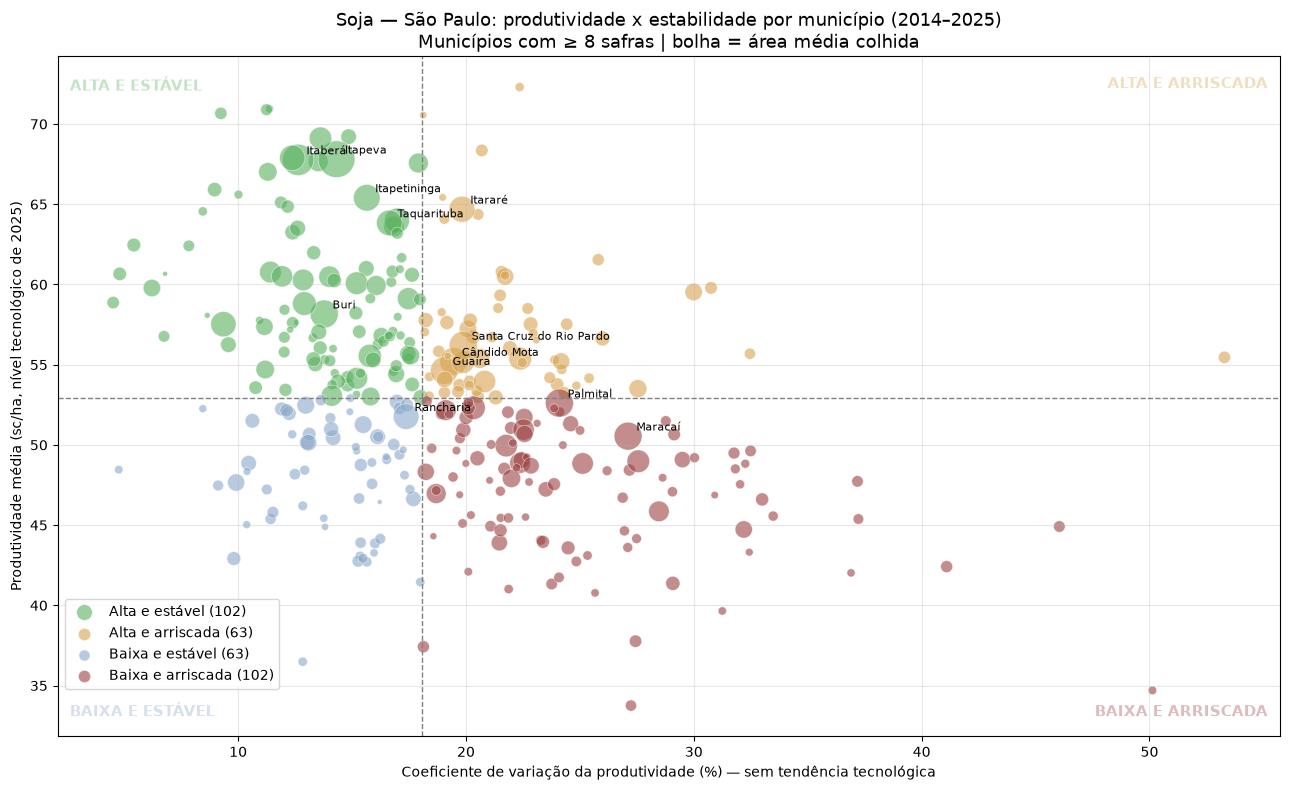

In [48]:
# Gráfico 1: produtividade x CV (dispersão em quadrantes)
# Tamanho da bolha = área média colhida | linhas tracejadas = medianas

N_ROTULOS = 12  # rotula os maiores produtores

fig, ax = plt.subplots(figsize=(13, 8))

for classe, cor in CORES_CLASSE.items():
    d = analise[analise["classe"] == classe]
    ax.scatter(
        d["cv_pct"], d["rend_medio_sc_ha"],
        s=np.sqrt(d["area_media_ha"]) * 2.5, c=cor, alpha=0.6,
        edgecolors="white", linewidths=0.5, label=f"{classe} ({len(d)})",
    )

ax.axvline(med_cv, color="gray", ls="--", lw=1)
ax.axhline(med_sc, color="gray", ls="--", lw=1)

for _, r in analise.nlargest(N_ROTULOS, "area_media_ha").iterrows():
    ax.annotate(r["Municipio"].replace(" - SP", ""), (r["cv_pct"], r["rend_medio_sc_ha"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Nome dos quadrantes nos cantos
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
kw = dict(fontsize=11, fontweight="bold", alpha=0.35)
ax.text(x0 + 0.01 * (x1 - x0), y1 - 0.03 * (y1 - y0), "ALTA E ESTÁVEL", color=CORES_CLASSE["Alta e estável"], va="top", **kw)
ax.text(x1 - 0.01 * (x1 - x0), y1 - 0.03 * (y1 - y0), "ALTA E ARRISCADA", color=CORES_CLASSE["Alta e arriscada"], va="top", ha="right", **kw)
ax.text(x0 + 0.01 * (x1 - x0), y0 + 0.03 * (y1 - y0), "BAIXA E ESTÁVEL", color=CORES_CLASSE["Baixa e estável"], **kw)
ax.text(x1 - 0.01 * (x1 - x0), y0 + 0.03 * (y1 - y0), "BAIXA E ARRISCADA", color=CORES_CLASSE["Baixa e arriscada"], ha="right", **kw)

ax.set_xlabel("Coeficiente de variação da produtividade (%) — sem tendência tecnológica")
ax.set_ylabel(f"Produtividade média (sc/ha, nível tecnológico de {ano_ref})")
ax.set_title(f"Soja — São Paulo: produtividade x estabilidade por município ({anos_periodo})\n"
             f"Municípios com ≥ {MIN_ANOS_CV} safras | bolha = área média colhida", fontsize=13)
ax.legend(loc="lower left", bbox_to_anchor=(0, 0.06), frameon=True, markerscale=0.6)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


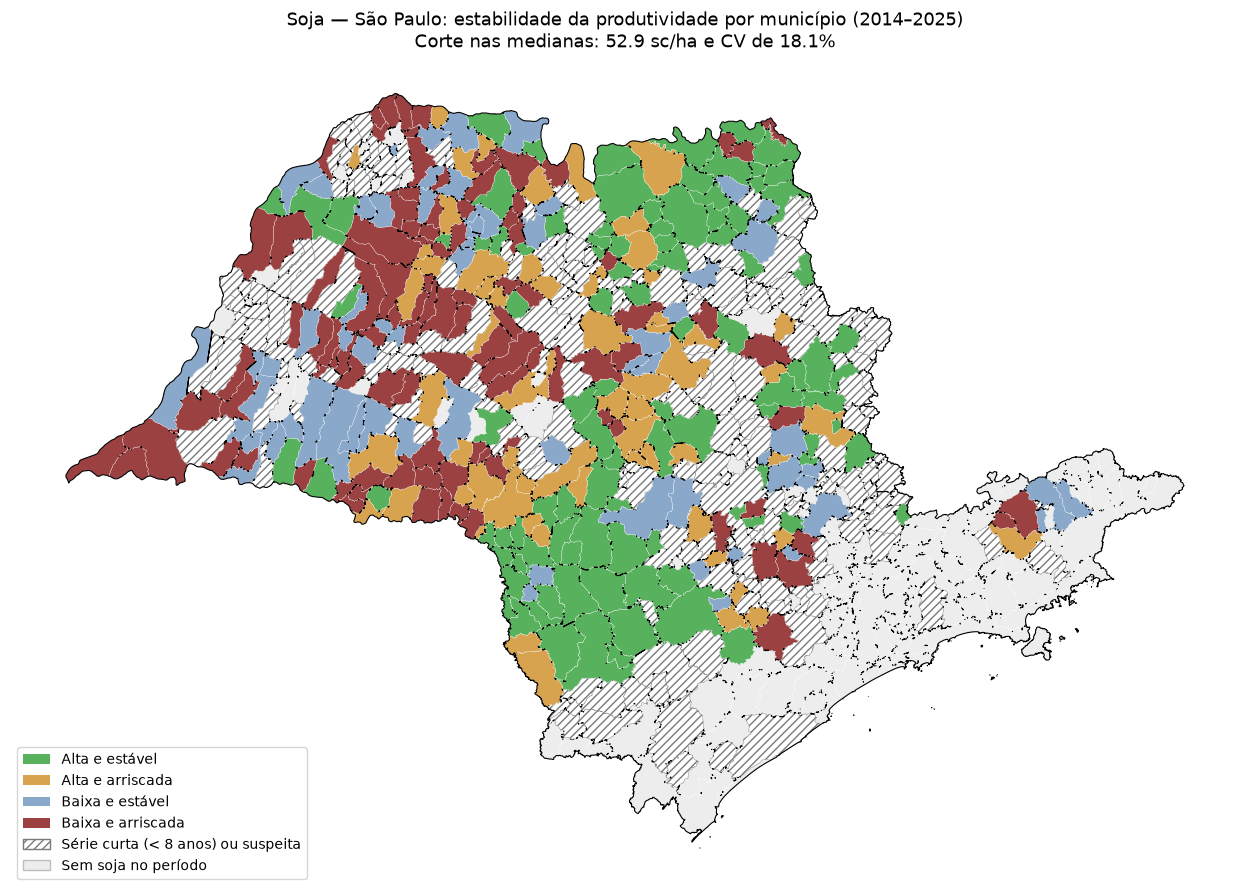

In [49]:
# Gráfico 2: mapa das classes de risco

mapa_cv = mun_sp.merge(analise[["cod_muni", "classe", "cv_pct"]], on="cod_muni", how="left")
mapa_cv = mapa_cv.merge(var_mun[["cod_muni", "n_anos"]], on="cod_muni", how="left")

fora_analise = mapa_cv[mapa_cv["classe"].isna() & mapa_cv["n_anos"].notna()]   # tem soja, mas série curta/suspeita
sem_soja_cv = mapa_cv[mapa_cv["n_anos"].isna()]

fig, ax = plt.subplots(figsize=(13, 9))
sem_soja_cv.plot(ax=ax, color="#EDEDED", edgecolor="white", linewidth=0.2)
fora_analise.plot(ax=ax, facecolor="white", edgecolor="#7A7A7A", hatch="////", linewidth=0.3)
for classe, cor in CORES_CLASSE.items():
    d = mapa_cv[mapa_cv["classe"] == classe]
    if len(d):
        d.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.2)
mun_sp.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.legend(
    handles=[Patch(facecolor=cor, label=classe) for classe, cor in CORES_CLASSE.items()]
    + [
        Patch(facecolor="white", edgecolor="#7A7A7A", hatch="////",
              label=f"Série curta (< {MIN_ANOS_CV} anos) ou suspeita"),
        Patch(facecolor="#EDEDED", edgecolor="#BDBDBD", label="Sem soja no período"),
    ],
    loc="lower left", frameon=True,
)
ax.set_title(f"Soja — São Paulo: estabilidade da produtividade por município ({anos_periodo})\n"
             f"Corte nas medianas: {med_sc:.1f} sc/ha e CV de {med_cv:.1f}%", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()


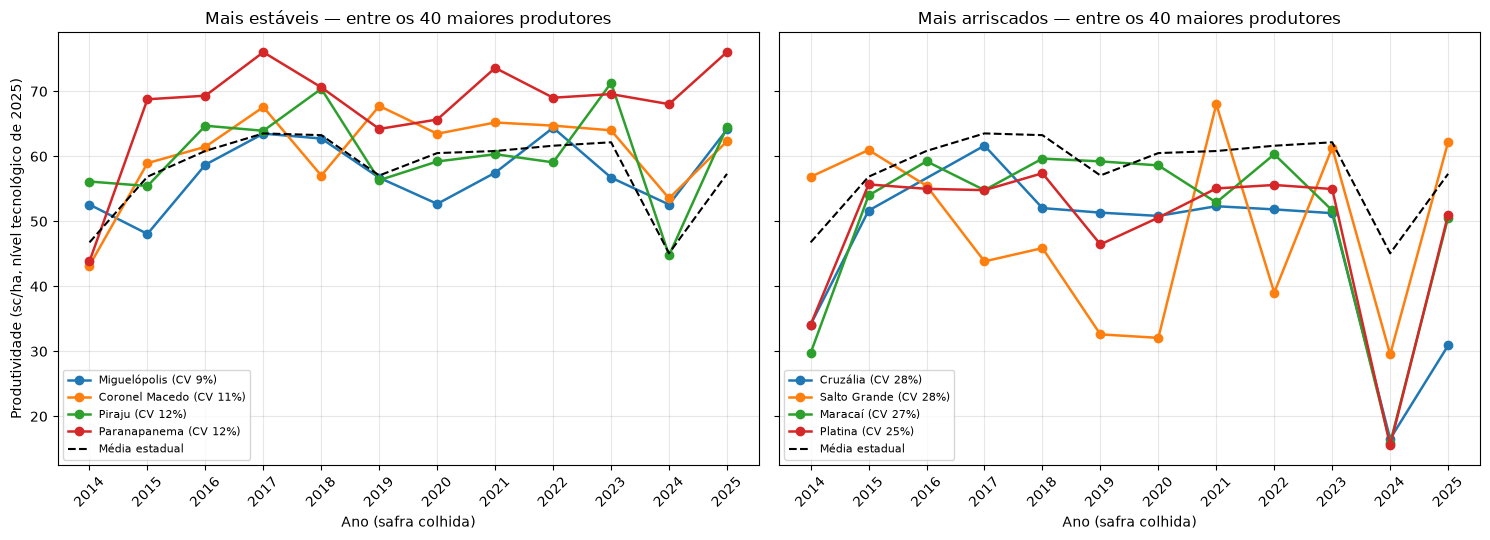

In [50]:
# Gráfico 3: séries dos mais estáveis x mais arriscados entre os grandes produtores
# (mostra na prática o que um CV baixo ou alto significa)

TOP_PRODUTORES = 40   # universo: os N municípios com maior área média
N_SERIES = 4

grandes = analise.nlargest(TOP_PRODUTORES, "area_media_ha")
estaveis = grandes.nsmallest(N_SERIES, "cv_pct")
arriscados = grandes.nlargest(N_SERIES, "cv_pct")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, grupo, titulo in [
    (axes[0], estaveis, "Mais estáveis"),
    (axes[1], arriscados, "Mais arriscados"),
]:
    for _, r in grupo.iterrows():
        s = base[base["Municipio (Código)"] == r["Municipio (Código)"]].sort_values("Ano")
        ax.plot(s["Ano"], s["rend_ajust_kg_ha"] / 60, "o-", lw=1.8,
                label=f"{r['Municipio'].replace(' - SP', '')} (CV {r['cv_pct']:.0f}%)")
    ax.plot(estadual.index, estadual["rend_kg_ha"] * fator_tec / 60, color="black",
            ls="--", lw=1.5, label="Média estadual")
    ax.set_title(f"{titulo} — entre os {TOP_PRODUTORES} maiores produtores")
    ax.set_xlabel("Ano (safra colhida)")
    ax.set_xticks(estadual.index)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel(f"Produtividade (sc/ha, nível tecnológico de {ano_ref})")
plt.tight_layout()
plt.show()


In [51]:
# Rankings (só municípios com área relevante, para não destacar quem planta 30 ha)

AREA_MIN_RANKING = 1000  # ha de área média colhida

cols = ["Municipio", "n_anos", "area_media_ha", "rend_medio_sc_ha", "cv_pct",
        "cv_bruto_pct", "queda_pior_ano_pct", "classe"]
relevantes = analise[analise["area_media_ha"] >= AREA_MIN_RANKING]

print(f"Municípios com área média >= {AREA_MIN_RANKING} ha: {len(relevantes)}")
print("\nTOP 10 — MAIS ESTÁVEIS (menor CV)")
print(relevantes.nsmallest(10, "cv_pct")[cols].round(1).to_string(index=False))
print("\nTOP 10 — MAIS ARRISCADOS (maior CV)")
print(relevantes.nlargest(10, "cv_pct")[cols].round(1).to_string(index=False))

print("\nSéries suspeitas (valores repetidos) — conferir antes de usar no modelo")
print(var_mun[var_mun["serie_suspeita"]].nlargest(10, "area_media_ha")
      [["Municipio", "n_anos", "area_media_ha", "n_repetidos", "cv_bruto_pct"]]
      .round(1).to_string(index=False))


Municípios com área média >= 1000 ha: 150

TOP 10 — MAIS ESTÁVEIS (menor CV)
          Municipio  n_anos  area_media_ha  rend_medio_sc_ha  cv_pct  cv_bruto_pct  queda_pior_ano_pct          classe
        Franca - SP      12         1016.7              58.9     4.5           6.6                -4.6  Alta e estável
       Itapira - SP      10         1399.5              60.7     4.8           6.6                -9.7  Alta e estável
       Itapura - SP      12         1499.1              62.5     5.4           7.1               -15.1  Alta e estável
     Nuporanga - SP      12         3981.7              59.8     6.2           7.4                -7.2  Alta e estável
         Iaras - SP      12         1808.1              65.9     9.0          10.7               -14.8  Alta e estável
  Miguelópolis - SP      12        17582.3              57.5     9.4          11.3               -16.5  Alta e estável
     Riolândia - SP      12         2556.2              56.2     9.6          10.4        

In [53]:
#Anos atípicos: anos em que a maioria ficou abaixo da tendência 

from scipy.stats import binomtest


LIMIAR_QUEBRA_MUN = -10   # município com desvio <= -10% = quebra local
LIMIAR_ATIPICO = 65       # % de municípios abaixo do normal para o ano ser "atípico ruim"
                          # (e <= 100 - LIMIAR_ATIPICO para "atípico bom")


cods_analise = set(analise["Municipio (Código)"])
dev = base[base["Municipio (Código)"].isin(cods_analise)].copy()


normal_mun = dev.groupby("Municipio (Código)")["rend_ajust_kg_ha"].median()
dev["normal_kg_ha"] = dev["Municipio (Código)"].map(normal_mun)
dev["desvio_mun_pct"] = (dev["rend_ajust_kg_ha"] / dev["normal_kg_ha"] - 1) * 100
dev["abaixo"] = dev["desvio_mun_pct"] < 0
dev["quebra_local"] = dev["desvio_mun_pct"] <= LIMIAR_QUEBRA_MUN
dev["area_quebra_ha"] = np.where(dev["quebra_local"], dev["area_colhida_ha"], 0)
dev["area_abaixo_ha"] = np.where(dev["abaixo"], dev["area_colhida_ha"], 0)


anos_atip = dev.groupby("Ano").agg(
    n_municipios=("Municipio (Código)", "nunique"),
    n_abaixo=("abaixo", "sum"),
    n_quebra=("quebra_local", "sum"),
    desvio_mediano_pct=("desvio_mun_pct", "median"),
    desvio_p10_pct=("desvio_mun_pct", lambda s: s.quantile(0.10)),
    area_total_ha=("area_colhida_ha", "sum"),
    area_abaixo_ha=("area_abaixo_ha", "sum"),
    area_quebra_ha=("area_quebra_ha", "sum"),
)
anos_atip["pct_mun_abaixo"] = anos_atip["n_abaixo"] / anos_atip["n_municipios"] * 100
anos_atip["pct_mun_quebra"] = anos_atip["n_quebra"] / anos_atip["n_municipios"] * 100
anos_atip["pct_area_abaixo"] = anos_atip["area_abaixo_ha"] / anos_atip["area_total_ha"] * 100
anos_atip["pct_area_quebra"] = anos_atip["area_quebra_ha"] / anos_atip["area_total_ha"] * 100

# Teste binomial: a proporção abaixo do normal é diferente de 50% por acaso?
anos_atip["p_valor"] = [
    binomtest(int(k), int(n), 0.5).pvalue
    for k, n in zip(anos_atip["n_abaixo"], anos_atip["n_municipios"])
]

anos_atip["tipo_ano"] = np.select(
    [anos_atip["pct_mun_abaixo"] >= LIMIAR_ATIPICO,
     anos_atip["pct_mun_abaixo"] <= 100 - LIMIAR_ATIPICO],
    ["Atípico ruim", "Atípico bom"],
    default="Normal",
)


# Junta com a visão estadual (desvio da tendência e quebra já calculados antes)
anos_atip = anos_atip.join(estadual[["desvio_pct", "quebra"]].rename(
    columns={"desvio_pct": "desvio_estadual_pct", "quebra": "quebra_estadual"}))


# Choque generalizado x localizado: o estado caiu porque muitos caíram ou porque poucos grandes caíram muito?
anos_atip["alcance"] = np.where(
    anos_atip["tipo_ano"] == "Atípico ruim", "Generalizado",
    np.where(anos_atip["quebra_estadual"], "Localizado (poucos, mas grandes)", "-"),
)

anos_ruins = list(anos_atip.index[anos_atip["tipo_ano"] == "Atípico ruim"])
anos_bons = list(anos_atip.index[anos_atip["tipo_ano"] == "Atípico bom"])

print("=" * 70)
print("ANOS ATÍPICOS — MUNICÍPIOS ABAIXO DO SEU PRÓPRIO NORMAL")
print("=" * 70)
print(f"Municípios analisados: {dev['Municipio (Código)'].nunique()} (mesmo universo da variabilidade)")
print(f"Critério: ano atípico ruim se >= {LIMIAR_ATIPICO}% dos municípios abaixo do normal")
print(f"Anos atípicos ruins: {anos_ruins or 'nenhum'}")
print(f"Anos atípicos bons:  {anos_bons or 'nenhum'}")
print()
cols_tab = ["n_municipios", "pct_mun_abaixo", "pct_mun_quebra", "pct_area_quebra",
            "desvio_mediano_pct", "desvio_p10_pct", "desvio_estadual_pct",
            "p_valor", "tipo_ano", "alcance"]
display(anos_atip[cols_tab].round({"pct_mun_abaixo": 1, "pct_mun_quebra": 1, "pct_area_quebra": 1,
                                    "desvio_mediano_pct": 1, "desvio_p10_pct": 1,
                                    "desvio_estadual_pct": 1, "p_valor": 4}))


ANOS ATÍPICOS — MUNICÍPIOS ABAIXO DO SEU PRÓPRIO NORMAL
Municípios analisados: 330 (mesmo universo da variabilidade)
Critério: ano atípico ruim se >= 65% dos municípios abaixo do normal
Anos atípicos ruins: [2014, 2024]
Anos atípicos bons:  [2017, 2018]



,n_municipios,pct_mun_abaixo,pct_mun_quebra,pct_area_quebra,desvio_mediano_pct,desvio_p10_pct,desvio_estadual_pct,p_valor,tipo_ano,alcance
Ano,,,,,,,,,,
2014,244,81.6,66.8,61.8,-21.1,-42.8,-23.2,0.0000,Atípico ruim,Generalizado
2015,260,60.8,33.8,26.1,-2.4,-29.3,-6.6,0.0006,Normal,-
2016,288,41.0,16.0,8.4,0.9,-16.3,-0.1,0.0026,Normal,-
2017,311,29.9,13.2,6.2,3.5,-12.8,4.3,0.0000,Atípico bom,-
2018,322,30.1,8.1,1.9,3.8,-8.5,3.8,0.0000,Atípico bom,-
2019,326,63.2,37.7,23.8,-3.4,-32.5,-6.3,0.0000,Normal,-
2020,326,40.2,10.1,5.4,1.0,-10.0,-0.7,0.0005,Normal,-
2021,328,46.6,16.5,6.1,0.3,-16.2,-0.2,0.2462,Normal,-
2022,329,38.3,8.8,4.4,1.6,-9.1,1.2,0.0000,Normal,-


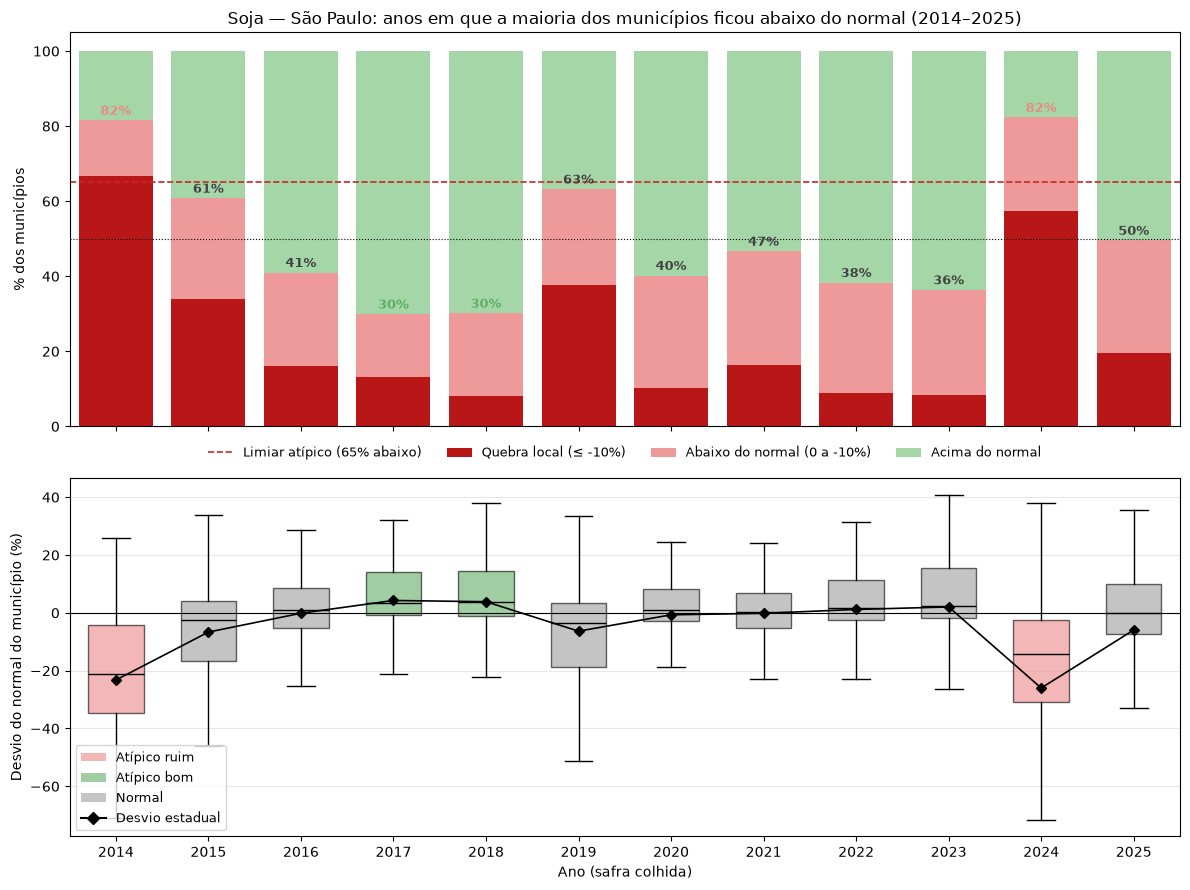

In [54]:
#gráfico: quantos caíram juntos e como se distribuíram os desvios

CORES_TIPO = {"Atípico ruim": "#EB8888", "Atípico bom": "#62AD66", "Normal": "#9E9E9E"}
anos_x = anos_atip.index.values

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [1.1, 1]}
)

# 1.1 Barras empilhadas: % de municípios em quebra, levemente abaixo e acima do normal
pct_quebra = anos_atip["pct_mun_quebra"]
pct_leve = anos_atip["pct_mun_abaixo"] - pct_quebra
pct_acima = 100 - anos_atip["pct_mun_abaixo"]

ax1.bar(anos_x, pct_quebra, color="#B91717", label=f"Quebra local (≤ {LIMIAR_QUEBRA_MUN}%)")
ax1.bar(anos_x, pct_leve, bottom=pct_quebra, color="#EF9A9A", label="Abaixo do normal (0 a -10%)")
ax1.bar(anos_x, pct_acima, bottom=anos_atip["pct_mun_abaixo"], color="#A5D6A7", label="Acima do normal")
ax1.axhline(50, color="black", lw=0.8, ls=":")
ax1.axhline(LIMIAR_ATIPICO, color="#C62828", lw=1.2, ls="--",
            label=f"Limiar atípico ({LIMIAR_ATIPICO}% abaixo)")

for ano, r in anos_atip.iterrows():
    ax1.text(ano, r["pct_mun_abaixo"] + 1.5, f"{r['pct_mun_abaixo']:.0f}%", ha="center",
             fontsize=9, fontweight="bold",
             color="#424242" if r["tipo_ano"] == "Normal" else CORES_TIPO[r["tipo_ano"]])

ax1.set_ylim(0, 105)
ax1.set_ylabel("% dos municípios")
ax1.set_title(f"Soja — São Paulo: anos em que a maioria dos municípios ficou abaixo do normal ({anos_periodo})")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9, frameon=False)

# 1.2 Boxplot dos desvios municipais: ano ruim generalizado = caixa inteira abaixo de zero
dados_box = [dev.loc[dev["Ano"] == a, "desvio_mun_pct"].values for a in anos_x]
bp = ax2.boxplot(dados_box, positions=anos_x, widths=0.6, patch_artist=True,
                 showfliers=False, medianprops={"color": "black"})
for caixa, tipo in zip(bp["boxes"], anos_atip["tipo_ano"]):
    caixa.set_facecolor(CORES_TIPO[tipo])
    caixa.set_alpha(0.6)
ax2.plot(anos_x, anos_atip["desvio_estadual_pct"], "D-", color="black", ms=5, lw=1.2,
         label="Desvio estadual da tendência")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Desvio do normal do município (%)")
ax2.set_xlabel("Ano (safra colhida)")
ax2.set_xticks(anos_x)
ax2.legend(handles=[Patch(facecolor=c, alpha=0.6, label=t) for t, c in CORES_TIPO.items()]
           + [plt.Line2D([], [], color="black", marker="D", label="Desvio estadual")],
           loc="lower left", fontsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

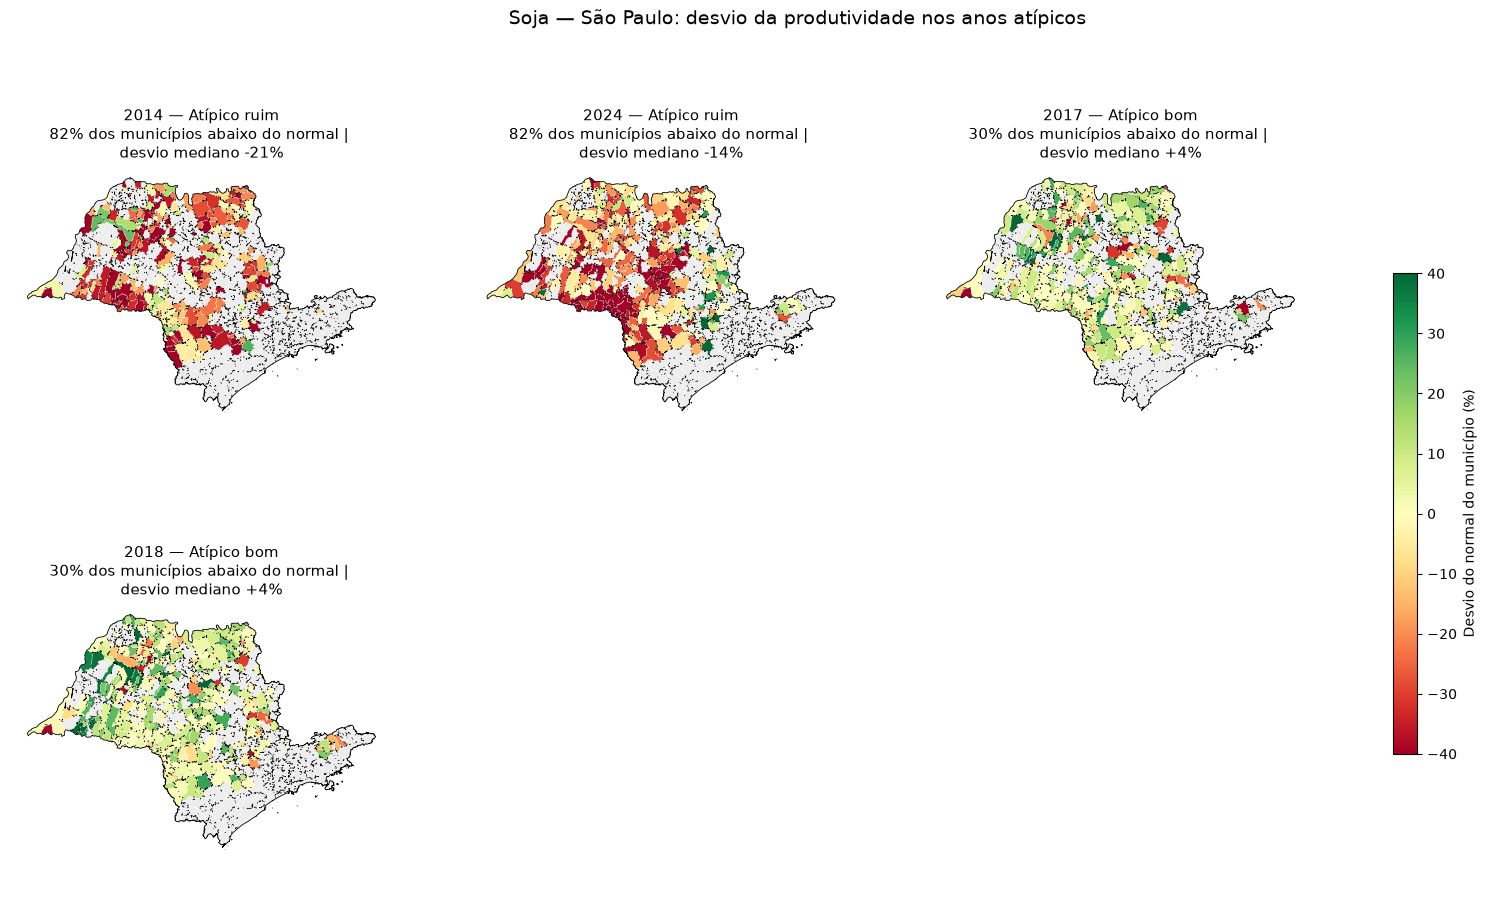

In [58]:
# Mapas dos anos atípicos

# Gráfico 2: mapas dos desvios nos anos atípicos


anos_mapa = anos_ruins + anos_bons
if not anos_mapa:  # se nenhum ano passar no limiar, mostra os 2 com mais municípios abaixo
    anos_mapa = list(anos_atip["pct_mun_abaixo"].nlargest(2).index)

LIM_COR = 40  # escala de cor de -40% a +40%
ncol = min(len(anos_mapa), 3)
nlin = int(np.ceil(len(anos_mapa) / ncol))

fig, axes = plt.subplots(nlin, ncol, figsize=(7 * ncol, 5.2 * nlin), squeeze=False)
for ax, ano in zip(axes.flat, anos_mapa):
    d_ano = dev.loc[dev["Ano"] == ano, ["Municipio (Código)", "desvio_mun_pct"]].copy()
    d_ano["cod_muni"] = d_ano["Municipio (Código)"].astype(int)
    m = mun_sp.merge(d_ano, on="cod_muni", how="left")

    m[m["desvio_mun_pct"].isna()].plot(ax=ax, color="#EDEDED", edgecolor="white", linewidth=0.2)
    m[m["desvio_mun_pct"].notna()].plot(
        ax=ax, column="desvio_mun_pct", cmap="RdYlGn", vmin=-LIM_COR, vmax=LIM_COR,
        edgecolor="white", linewidth=0.2,
    )
    mun_sp.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.6)

    r = anos_atip.loc[ano]
    ax.set_title(f"{ano} — {r['tipo_ano']}\n{r['pct_mun_abaixo']:.0f}% dos municípios abaixo do normal | \n"
                 f"desvio mediano {r['desvio_mediano_pct']:+.0f}%", fontsize=11)
    ax.set_axis_off()

for ax in list(axes.flat)[len(anos_mapa):]:
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(-LIM_COR, LIM_COR))
fig.colorbar(sm, ax=axes, shrink=0.6, label="Desvio do normal do município (%)")
fig.suptitle("Soja — São Paulo: desvio da produtividade nos anos atípicos", fontsize=14)
plt.show()

In [59]:
# Destaques e base para cruzar com clima

# Destaques por ano atípico + base pronta para cruzar com clima

AREA_MIN_DESTAQUE = 1000  # ha colhidos no ano

for ano in anos_ruins:
    d = dev[(dev["Ano"] == ano) & (dev["area_colhida_ha"] >= AREA_MIN_DESTAQUE)]
    print(f"\n{ano} — maiores quedas entre municípios com >= {AREA_MIN_DESTAQUE} ha colhidos")
    print(d.nsmallest(10, "desvio_mun_pct")
          .assign(normal_sc_ha=lambda x: x["normal_kg_ha"] / 60,
                  rend_ajust_sc_ha=lambda x: x["rend_ajust_kg_ha"] / 60)
          [["Municipio", "area_colhida_ha", "normal_sc_ha", "rend_ajust_sc_ha", "desvio_mun_pct"]]
          .round(1).to_string(index=False))

# Municípios que caem em quase todo ano ruim: mais sensíveis ao choque comum
if anos_ruins:
    sens = (dev[dev["Ano"].isin(anos_ruins)]
            .groupby(["Municipio (Código)", "Municipio"])
            .agg(anos_ruins_com_dado=("Ano", "nunique"),
                 vezes_em_quebra=("quebra_local", "sum"),
                 desvio_medio_anos_ruins=("desvio_mun_pct", "mean"))
            .reset_index()
            .merge(analise[["Municipio (Código)", "area_media_ha", "cv_pct", "classe"]],
                   on="Municipio (Código)"))
    print(f"\nMAIS SENSÍVEIS AOS ANOS RUINS ({anos_ruins}) — área média >= {AREA_MIN_DESTAQUE} ha")
    print(sens[sens["area_media_ha"] >= AREA_MIN_DESTAQUE]
          .nsmallest(10, "desvio_medio_anos_ruins")
          .drop(columns="Municipio (Código)").round(1).to_string(index=False))

# Base município x ano com o desvio: é ela que será cruzada com chuva/temperatura na próxima etapa
desvios_mun_ano = dev[["Municipio (Código)", "Municipio", "Ano", "area_colhida_ha",
                       "rendimento_kg_ha", "rend_ajust_kg_ha", "normal_kg_ha",
                       "desvio_mun_pct", "quebra_local"]].merge(
    anos_atip[["tipo_ano"]], left_on="Ano", right_index=True)
desvios_mun_ano["cod_muni"] = desvios_mun_ano["Municipio (Código)"].astype(int)
print(f"\ndesvios_mun_ano: {len(desvios_mun_ano)} linhas (município x ano)")


2014 — maiores quedas entre municípios com >= 1000 ha colhidos
              Municipio  area_colhida_ha  normal_sc_ha  rend_ajust_sc_ha  desvio_mun_pct
           Itararé - SP          16000.0          65.9              28.4           -56.9
Paraguaçu Paulista - SP           3400.0          60.2              28.4           -52.8
          Palmital - SP          20500.0          57.7              28.4           -50.7
          Riversul - SP           2500.0          64.1              34.1           -46.8
      Pilar do Sul - SP           1800.0          62.7              34.1           -45.6
           Maracaí - SP          22140.0          54.4              29.7           -45.3
         Bebedouro - SP           1500.0          62.2              34.1           -45.2
         Rancharia - SP          15033.0          51.3              28.5           -44.4
          Castilho - SP           2200.0          40.1              22.7           -43.2
        Guararapes - SP           3360.0      

In [60]:
#Validação com a Conab: comparar a média de SP do IBGE com a série histórica da Conab.

#Carregando a série histórica da Conab (produção, área e produtividade) para SP

import re
import unicodedata

FONTE_CONAB = "txt"
URL_CONAB_TXT = "https://portaldeinformacoes.conab.gov.br/downloads/arquivos/SerieHistoricaGraos.txt"
CAMINHO_CONAB_XLS = "SojaSerieHist.xls"
UF = "SP"


def normalizar(txt):
    """minúsculas e sem acento, para comparar nomes de colunas/abas"""
    txt = unicodedata.normalize("NFKD", str(txt)).encode("ascii", "ignore").decode()
    return txt.lower().strip()


def safra_para_ano(safra):
    """'2023/24' -> 2024 (ano da colheita, mesmo padrão da PAM)"""
    m = re.search(r"(\d{4})\s*/\s*\d{2,4}", str(safra))
    return int(m.group(1)) + 1 if m else np.nan


def achar_coluna(df, *trechos, excluir=()):
    """primeira coluna cujo nome normalizado contém todos os trechos"""
    for c in df.columns:
        n = normalizar(c)
        if all(t in n for t in trechos) and not any(e in n for e in excluir):
            return c
    raise KeyError(f"Coluna com {trechos} não encontrada. Colunas: {list(df.columns)}")


def ler_conab_txt(url, uf):
    for enc in ("utf-8", "latin-1"):
        try:
            bruto = pd.read_csv(url, sep=";", encoding=enc, dtype=str)
            break
        except UnicodeDecodeError:
            continue
    bruto.columns = [c.strip() for c in bruto.columns]

    c_safra = achar_coluna(bruto, "ano")
    c_uf = achar_coluna(bruto, "uf")
    c_prod = achar_coluna(bruto, "produto", excluir=("id",))
    c_area = achar_coluna(bruto, "area")
    c_producao = achar_coluna(bruto, "producao")

    d = bruto[(bruto[c_uf].str.strip().str.upper() == uf)
              & (bruto[c_prod].map(normalizar).str.contains("soja"))].copy()
    for c in (c_area, c_producao):
        d[c] = pd.to_numeric(d[c].str.replace(",", "."), errors="coerce")
    d["Ano"] = d[c_safra].map(safra_para_ano)

    # Soma por ano caso a soja venha dividida em mais de uma linha (ex.: safras diferentes)
    out = d.groupby("Ano").agg(conab_area_mil_ha=(c_area, "sum"),
                               conab_producao_mil_t=(c_producao, "sum"))
    out["conab_safra"] = d.groupby("Ano")[c_safra].first()
    return out


def ler_conab_xls(caminho, uf):
    abas = pd.read_excel(caminho, sheet_name=None, header=None)

    def serie_da_aba(*trechos):
        nome = next((n for n in abas if all(t in normalizar(n) for t in trechos)), None)
        if nome is None:
            raise KeyError(f"Aba com {trechos} não encontrada. Abas: {list(abas)}")
        bruto = abas[nome]
        padrao = r"\d{4}\s*/\s*\d{2}"
        # cabeçalho = linha com mais células no formato de safra
        n_safras = bruto.apply(lambda r: r.astype(str).str.contains(padrao).sum(), axis=1)
        cab = bruto.loc[n_safras.idxmax()]
        # linha da UF = primeira linha com "SP" isolado em alguma das 3 primeiras colunas
        eh_uf = bruto.iloc[:, :3].apply(lambda c: c.astype(str).str.strip().str.upper() == uf).any(axis=1)
        if not eh_uf.any():
            raise KeyError(f"Linha da UF '{uf}' não encontrada na aba '{nome}'")
        linha = bruto[eh_uf].iloc[0]
        valores = {
            safra_para_ano(c): pd.to_numeric(v, errors="coerce")
            for c, v in zip(cab, linha) if re.search(padrao, str(c))
        }
        safras = {safra_para_ano(c): re.search(padrao, str(c)).group(0).replace(" ", "")
                  for c in cab if re.search(padrao, str(c))}
        return pd.Series(valores, dtype=float), safras

    area, safras = serie_da_aba("area")
    producao, _ = serie_da_aba("producao")
    out = pd.DataFrame({"conab_area_mil_ha": area, "conab_producao_mil_t": producao})
    out["conab_safra"] = pd.Series(safras)
    out.index.name = "Ano"
    return out


conab = ler_conab_txt(URL_CONAB_TXT, UF) if FONTE_CONAB == "txt" else ler_conab_xls(CAMINHO_CONAB_XLS, UF)

# Produtividade recalculada (mil t / mil ha -> kg/ha) para não depender do arredondamento da fonte
conab["conab_rend_kg_ha"] = conab["conab_producao_mil_t"] / conab["conab_area_mil_ha"] * 1000
conab = conab.dropna(subset=["conab_rend_kg_ha"]).sort_index()

print(f"Conab — soja {UF}: {len(conab)} safras ({conab['conab_safra'].iloc[0]} a {conab['conab_safra'].iloc[-1]})")
display(conab.tail(12).round(1))

Conab — soja SP: 50 safras (1976/77              a 2025/26             )


,conab_area_mil_ha,conab_producao_mil_t,conab_safra,conab_rend_kg_ha
Ano,,,,
2015,796.8,2366.5,2014/15,2970.0
2016,857.6,2843.8,2015/16,3316.0
2017,895.3,3084.3,2016/17,3445.0
2018,961.6,3409.8,2017/18,3546.0
2019,996.0,3227.7,2018/19,3240.7
2020,1110.0,3959.0,2019/20,3566.7
2021,1162.0,4299.4,2020/21,3700.0
2022,1215.5,4202.0,2021/22,3457.0
2023,1296.9,4936.0,2022/23,3806.0


In [61]:
#IBGE oficial no nivel estadual e checagem da agregação municipal

dados_uf = sidrapy.get_table(
    table_code="5457",
    territorial_level="3",
    ibge_territorial_code="35",
    variable="8331,216,214,112",   # área plantada, área colhida, produção (t), rendimento (kg/ha)
    classifications={"782": "40124"},
    period="last 12",
)
dados_uf = dados_uf.iloc[1:].copy()   # 1ª linha é o cabeçalho descritivo
dados_uf["Valor"] = pd.to_numeric(dados_uf["V"], errors="coerce")
dados_uf["Ano"] = dados_uf["D2N"].astype(int)

ibge_uf = dados_uf.pivot_table(index="Ano", columns="D3C", values="Valor", aggfunc="first")
ibge_uf = ibge_uf.rename(columns={
    "8331": "ibge_area_plantada_ha", "216": "ibge_area_colhida_ha",
    "214": "ibge_producao_t", "112": "ibge_rend_kg_ha",
})
ibge_uf.columns.name = None
ibge_uf["ibge_rend_plantada_kg_ha"] = ibge_uf["ibge_producao_t"] * 1000 / ibge_uf["ibge_area_plantada_ha"]
ibge_uf["perda_area_pct"] = (1 - ibge_uf["ibge_area_colhida_ha"] / ibge_uf["ibge_area_plantada_ha"]) * 100

# Checagem: o estadual oficial bate com a agregação municipal feita no início do projeto?
chk = ibge_uf[["ibge_rend_kg_ha"]].join(estadual[["rend_kg_ha"]].rename(columns={"rend_kg_ha": "agregado_mun_kg_ha"}))
chk["dif_pct"] = (chk["agregado_mun_kg_ha"] / chk["ibge_rend_kg_ha"] - 1) * 100
print("Checagem IBGE: estadual oficial x agregação dos municípios (diferença deve ser ~0%)")
display(chk.round(2))


Checagem IBGE: estadual oficial x agregação dos municípios (diferença deve ser ~0%)


,ibge_rend_kg_ha,agregado_mun_kg_ha,dif_pct
Ano,,,
2014,2468,2467.89,-0.00
2015,3039,3038.53,-0.02
2016,3290,3290.32,0.01
2017,3478,3477.78,-0.01
2018,3505,3504.72,-0.01
2019,3199,3198.56,-0.01
2020,3431,3431.30,0.01
2021,3489,3489.20,0.01
2022,3577,3576.50,-0.01


In [62]:
#Comparação metricas

comp = ibge_uf.join(conab, how="inner")
comp["conab_area_ha"] = comp["conab_area_mil_ha"] * 1000
comp["conab_producao_t"] = comp["conab_producao_mil_t"] * 1000

# Diferenças (positivo = IBGE acima da Conab)
comp["dif_rend_kg_ha"] = comp["ibge_rend_kg_ha"] - comp["conab_rend_kg_ha"]
comp["dif_rend_pct"] = (comp["ibge_rend_kg_ha"] / comp["conab_rend_kg_ha"] - 1) * 100
comp["dif_rend_plantada_pct"] = (comp["ibge_rend_plantada_kg_ha"] / comp["conab_rend_kg_ha"] - 1) * 100
comp["dif_area_pct"] = (comp["ibge_area_plantada_ha"] / comp["conab_area_ha"] - 1) * 100
comp["dif_producao_pct"] = (comp["ibge_producao_t"] / comp["conab_producao_t"] - 1) * 100

# Desvio de cada fonte em relação à SUA PRÓPRIA tendência (Theil-Sen), para comparar anos de quebra
for fonte in ("ibge", "conab"):
    s = comp[f"{fonte}_rend_kg_ha"]
    inc, icp, _, _ = theilslopes(s.values, comp.index.values, 0.95)
    comp[f"{fonte}_tend_kg_ha"] = icp + inc * comp.index.values
    comp[f"{fonte}_desvio_pct"] = (s / comp[f"{fonte}_tend_kg_ha"] - 1) * 100
    comp[f"{fonte}_quebra"] = comp[f"{fonte}_desvio_pct"] <= LIMIAR_QUEBRA_PCT

ib, cn = comp["ibge_rend_kg_ha"], comp["conab_rend_kg_ha"]
metricas = {
    "Anos comparados": f"{comp.index.min()}–{comp.index.max()} ({len(comp)} safras)",
    "Viés médio (IBGE - Conab)": f"{comp['dif_rend_kg_ha'].mean():+.0f} kg/ha ({comp['dif_rend_kg_ha'].mean() / 60:+.1f} sc/ha)",
    "Erro absoluto médio (MAE)": f"{comp['dif_rend_kg_ha'].abs().mean():.0f} kg/ha ({comp['dif_rend_kg_ha'].abs().mean() / 60:.1f} sc/ha)",
    "Erro percentual absoluto médio (MAPE)": f"{comp['dif_rend_pct'].abs().mean():.1f}%",
    "MAPE com IBGE sobre área plantada": f"{comp['dif_rend_plantada_pct'].abs().mean():.1f}%",
    "Correlação dos níveis": f"{ib.corr(cn):.2f}",
    "Correlação das variações ano a ano": f"{ib.diff().corr(cn.diff()):.2f}",
    "Correlação dos desvios da tendência": f"{comp['ibge_desvio_pct'].corr(comp['conab_desvio_pct']):.2f}",
    "Quebras IBGE": str(list(comp.index[comp["ibge_quebra"]]) or "nenhuma"),
    "Quebras Conab": str(list(comp.index[comp["conab_quebra"]]) or "nenhuma"),
    "Anos com sinal oposto (uma acima, outra abaixo da tendência)":
        str(list(comp.index[np.sign(comp["ibge_desvio_pct"]) != np.sign(comp["conab_desvio_pct"])]) or "nenhum"),
}

print("=" * 70)
print(f"VALIDAÇÃO — PRODUTIVIDADE DE SOJA EM {UF}: IBGE (PAM) x CONAB")
print("=" * 70)
for k, v in metricas.items():
    print(f"{k:<62} {v}")
print()

cols_comp = ["conab_safra", "ibge_rend_kg_ha", "conab_rend_kg_ha", "dif_rend_pct",
             "dif_rend_plantada_pct", "dif_area_pct", "dif_producao_pct",
             "perda_area_pct", "ibge_desvio_pct", "conab_desvio_pct"]
display(comp[cols_comp].round(1))

VALIDAÇÃO — PRODUTIVIDADE DE SOJA EM SP: IBGE (PAM) x CONAB
Anos comparados                                                2014–2025 (12 safras)
Viés médio (IBGE - Conab)                                      -65 kg/ha (-1.1 sc/ha)
Erro absoluto médio (MAE)                                      139 kg/ha (2.3 sc/ha)
Erro percentual absoluto médio (MAPE)                          4.2%
MAPE com IBGE sobre área plantada                              4.4%
Correlação dos níveis                                          0.94
Correlação das variações ano a ano                             0.96
Correlação dos desvios da tendência                            0.95
Quebras IBGE                                                   [2014, 2024]
Quebras Conab                                                  [2014, 2024]
Anos com sinal oposto (uma acima, outra abaixo da tendência)   [2016, 2020, 2021, 2022, 2025]



,conab_safra,ibge_rend_kg_ha,conab_rend_kg_ha,dif_rend_pct,dif_rend_plantada_pct,dif_area_pct,dif_producao_pct,perda_area_pct,ibge_desvio_pct,conab_desvio_pct
Ano,,,,,,,,,,
2014,2013/14,2468,2246.0,9.9,9.7,-7.7,1.2,0.1,-23.2,-26.9
2015,2014/15,3039,2970.0,2.3,2.3,-0.6,1.7,0.0,-6.6,-5.5
2016,2015/16,3290,3316.0,-0.8,-0.8,-1.0,-1.8,0.0,-0.1,3.3
2017,2016/17,3478,3445.0,1.0,1.0,5.7,6.7,0.0,4.3,5.0
2018,2017/18,3505,3546.0,-1.2,-1.2,1.2,0.0,0.0,3.9,5.9
2019,2018/19,3199,3240.7,-1.3,-1.3,8.5,7.1,0.0,-6.3,-5.2
2020,2019/20,3431,3566.7,-3.8,-3.8,2.1,-1.8,0.0,-0.7,2.3
2021,2020/21,3489,3700.0,-5.7,-5.7,3.2,-2.7,0.0,-0.2,4.1
2022,2021/22,3577,3457.0,3.5,3.5,3.0,6.6,0.0,1.2,-4.6


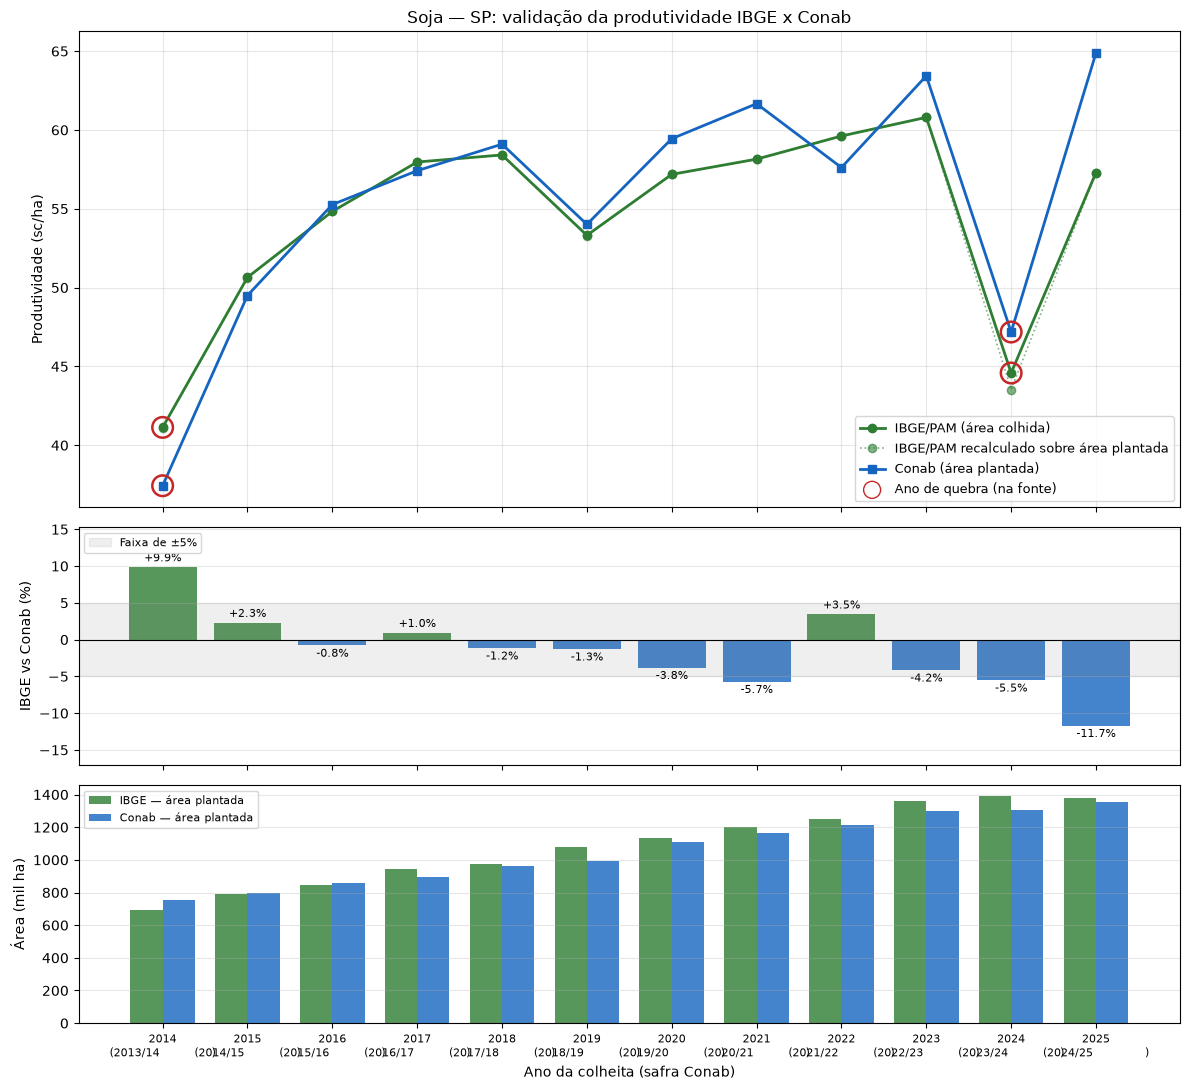

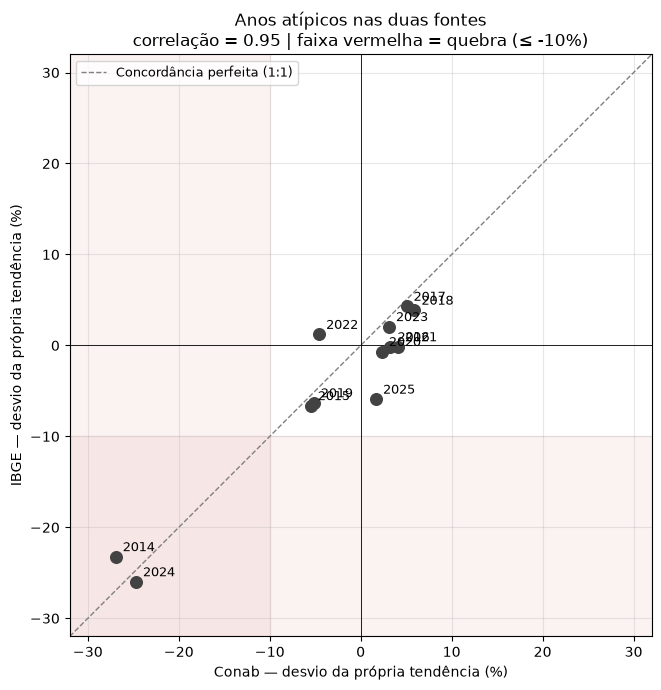

In [63]:
#Graficos 

COR_IBGE, COR_CONAB = "#2E7D32", "#1565C0"
anos_c = comp.index.values
rotulos = [f"{a}\n({s})" for a, s in zip(anos_c, comp["conab_safra"])]

# Gráfico 1: séries de produtividade, diferença % e área
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 11), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]}
)

ax1.plot(anos_c, comp["ibge_rend_kg_ha"] / 60, "o-", color=COR_IBGE, lw=2,
         label="IBGE/PAM (área colhida)")
ax1.plot(anos_c, comp["ibge_rend_plantada_kg_ha"] / 60, "o:", color=COR_IBGE, lw=1.2, alpha=0.6,
         label="IBGE/PAM recalculado sobre área plantada")
ax1.plot(anos_c, comp["conab_rend_kg_ha"] / 60, "s-", color=COR_CONAB, lw=2,
         label="Conab (área plantada)")
for fonte, cor in (("ibge", COR_IBGE), ("conab", COR_CONAB)):
    q = comp[comp[f"{fonte}_quebra"]]
    ax1.scatter(q.index, q[f"{fonte}_rend_kg_ha"] / 60, s=220, facecolors="none",
                edgecolors="#C62828", linewidths=1.8, zorder=5)
ax1.scatter([], [], s=150, facecolors="none", edgecolors="#C62828", label="Ano de quebra (na fonte)")
ax1.set_ylabel("Produtividade (sc/ha)")
ax1.set_title(f"Soja — {UF}: validação da produtividade IBGE x Conab")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

cores_dif = np.where(comp["dif_rend_pct"] >= 0, COR_IBGE, COR_CONAB)
ax2.bar(anos_c, comp["dif_rend_pct"], color=cores_dif, alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhspan(-5, 5, color="gray", alpha=0.12, label="Faixa de ±5%")
for a, v in zip(anos_c, comp["dif_rend_pct"]):
    ax2.text(a, v + (0.4 if v >= 0 else -0.4), f"{v:+.1f}%", ha="center",
             va="bottom" if v >= 0 else "top", fontsize=8)
ax2.margins(y=0.25)
ax2.set_ylabel("IBGE vs Conab (%)")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3, axis="y")

larg = 0.38
ax3.bar(anos_c - larg / 2, comp["ibge_area_plantada_ha"] / 1000, larg, color=COR_IBGE,
        alpha=0.8, label="IBGE — área plantada")
ax3.bar(anos_c + larg / 2, comp["conab_area_ha"] / 1000, larg, color=COR_CONAB,
        alpha=0.8, label="Conab — área plantada")
ax3.set_ylabel("Área (mil ha)")
ax3.set_xticks(anos_c)
ax3.set_xticklabels(rotulos, fontsize=8)
ax3.set_xlabel("Ano da colheita (safra Conab)")
ax3.legend(loc="upper left", fontsize=8)
ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Gráfico 2: as duas fontes enxergam os mesmos anos bons e ruins?
fig, ax = plt.subplots(figsize=(8, 7))
x, y = comp["conab_desvio_pct"], comp["ibge_desvio_pct"]
lim = np.ceil(max(x.abs().max(), y.abs().max()) / 5) * 5 + 2

ax.axhspan(-lim, LIMIAR_QUEBRA_PCT, color="#C62828", alpha=0.06)
ax.axvspan(-lim, LIMIAR_QUEBRA_PCT, color="#C62828", alpha=0.06)
ax.plot([-lim, lim], [-lim, lim], "--", color="gray", lw=1, label="Concordância perfeita (1:1)")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(0, color="black", lw=0.6)
ax.scatter(x, y, s=70, color="#424242", zorder=3)
for a in comp.index:
    ax.annotate(str(a), (x[a], y[a]), textcoords="offset points", xytext=(5, 4), fontsize=9)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("Conab — desvio da própria tendência (%)")
ax.set_ylabel("IBGE — desvio da própria tendência (%)")
ax.set_title(f"Anos atípicos nas duas fontes\ncorrelação = "
             f"{comp['ibge_desvio_pct'].corr(comp['conab_desvio_pct']):.2f} | "
             f"faixa vermelha = quebra (≤ {LIMIAR_QUEBRA_PCT}%)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
#Clima

# O centroide é calculado numa projeção métrica (SIRGAS 2000 / Brazil Polyconic, EPSG:5880)
# e convertido de volta para lat/lon. Calcular direto em graus gera aviso e um ponto levemente deslocado.

municipios_soja = set(var_mun["cod_muni"])   # todos que colheram soja no período (não só os da análise de CV)

mun_clima = mun_sp[mun_sp["cod_muni"].isin(municipios_soja)][["cod_muni", "name_muni", "geometry"]].copy()
centroides = mun_clima.to_crs(5880).centroid.to_crs(4674)
mun_clima["lat"] = centroides.y.round(4)
mun_clima["lon"] = centroides.x.round(4)

# Município com formato muito irregular pode ter o centroide fora do próprio território
fora = ~mun_clima.to_crs(5880).contains(mun_clima.to_crs(5880).centroid)
if fora.any():
    print(f"{fora.sum()} município(s) com centroide fora do polígono — usando ponto interno:")
    print(mun_clima.loc[fora, "name_muni"].tolist())
    pto = mun_clima.loc[fora].to_crs(5880).representative_point().to_crs(4674)
    mun_clima.loc[fora, "lat"] = pto.y.round(4)
    mun_clima.loc[fora, "lon"] = pto.x.round(4)

mun_clima = pd.DataFrame(mun_clima.drop(columns="geometry"))
print(f"Municípios para baixar clima: {len(mun_clima)}")
display(mun_clima.head())


2 município(s) com centroide fora do polígono — usando ponto interno:
['Guararapes', 'Pirapozinho']
Municípios para baixar clima: 514


,cod_muni,name_muni,lat,lon
0,3500105,Adamantina,-21.5766,-51.0568
1,3500204,Adolfo,-21.2887,-49.6532
2,3500303,Aguaí,-22.0500,-47.0403
3,3500402,Águas da Prata,-21.9136,-46.6917
4,3500501,Águas de Lindóia,-22.4748,-46.6037


In [65]:
#Download no NASA POWER

import os
import time
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

URL_POWER = "https://power.larc.nasa.gov/api/temporal/daily/point"
PARAMETROS = ["PRECTOTCORR", "T2M_MAX", "T2M_MIN", "ALLSKY_SFC_SW_DWN"]
PASTA_CACHE = "cache_power"
N_THREADS = 4            # a NASA pede uso moderado; 4 requisições simultâneas é seguro
MAX_TENTATIVAS = 5

# Período: da primeira safra (out do ano anterior à 1ª colheita) até mar da última colheita
ANO_INI, ANO_FIM = int(base["Ano"].min()), int(base["Ano"].max())
DATA_INI = f"{ANO_INI - 1}1001"
DATA_FIM = f"{ANO_FIM}0331"

os.makedirs(PASTA_CACHE, exist_ok=True)
sessao = requests.Session()


def baixar_power(cod_muni, lat, lon):
    arq = os.path.join(PASTA_CACHE, f"{cod_muni}.csv")
    if os.path.exists(arq):
        return cod_muni, "cache"

    params = {
        "parameters": ",".join(PARAMETROS),
        "community": "AG",
        "latitude": lat,
        "longitude": lon,
        "start": DATA_INI,
        "end": DATA_FIM,
        "format": "JSON",
        "time-standard": "LST",   # dia no horário local
    }
    for tentativa in range(1, MAX_TENTATIVAS + 1):
        try:
            r = sessao.get(URL_POWER, params=params, timeout=120)
            if r.status_code == 429 or r.status_code >= 500:   # limite de uso / servidor ocupado
                raise requests.HTTPError(f"HTTP {r.status_code}")
            r.raise_for_status()
            js = r.json()
            fill = js.get("header", {}).get("fill_value", -999)
            df = pd.DataFrame(js["properties"]["parameter"])
            df.index = pd.to_datetime(df.index, format="%Y%m%d")
            df.index.name = "data"
            df = df.mask(df <= fill)            # -999 = sem dado
            df.to_csv(arq)
            return cod_muni, "ok"
        except Exception as e:
            if tentativa == MAX_TENTATIVAS:
                return cod_muni, f"erro: {e}"
            time.sleep(2 ** tentativa)          # espera 2, 4, 8, 16 s


inicio = time.time()
status = {}
with ThreadPoolExecutor(max_workers=N_THREADS) as ex:
    futuros = [ex.submit(baixar_power, r.cod_muni, r.lat, r.lon) for r in mun_clima.itertuples()]
    for i, f in enumerate(as_completed(futuros), 1):
        cod, st = f.result()
        status[cod] = st
        if i % 50 == 0 or i == len(futuros):
            print(f"{i}/{len(futuros)} municípios | {time.time() - inicio:.0f}s")

falhas = {c: s for c, s in status.items() if s.startswith("erro")}
print(f"\nBaixados: {sum(s == 'ok' for s in status.values())} | do cache: "
      f"{sum(s == 'cache' for s in status.values())} | falhas: {len(falhas)}")
if falhas:
    print("Rode a célula de novo para tentar só os que falharam:", list(falhas)[:10])

50/514 municípios | 18s
100/514 municípios | 33s
150/514 municípios | 46s
200/514 municípios | 61s
250/514 municípios | 78s
300/514 municípios | 94s
350/514 municípios | 107s
400/514 municípios | 122s
450/514 municípios | 136s
500/514 municípios | 150s
514/514 municípios | 154s

Baixados: 514 | do cache: 0 | falhas: 0


In [66]:
#Junção dos arquivos diários em uma única tabela

partes = []
for cod in mun_clima["cod_muni"]:
    arq = os.path.join(PASTA_CACHE, f"{cod}.csv")
    if os.path.exists(arq):
        d = pd.read_csv(arq, parse_dates=["data"])
        d["cod_muni"] = cod
        partes.append(d)

clima_diario = pd.concat(partes, ignore_index=True)
clima_diario = clima_diario.rename(columns={
    "PRECTOTCORR": "chuva_mm", "T2M_MAX": "tmax_c", "T2M_MIN": "tmin_c",
    "ALLSKY_SFC_SW_DWN": "radiacao_mj_m2",
})

print(f"clima_diario: {len(clima_diario):,} linhas | {clima_diario['cod_muni'].nunique()} municípios | "
      f"{clima_diario['data'].min():%d/%m/%Y} a {clima_diario['data'].max():%d/%m/%Y}")
print("\n% de dias sem dado por variável:")
print((clima_diario[["chuva_mm", "tmax_c", "tmin_c", "radiacao_mj_m2"]].isna().mean() * 100).round(2))

clima_diario: 2,158,800 linhas | 514 municípios | 01/10/2013 a 31/03/2025

% de dias sem dado por variável:
chuva_mm          0.0
tmax_c            0.0
tmin_c            0.0
radiacao_mj_m2    0.0
dtype: float64


In [67]:
#Agregação pela janela safra

# Ano da PAM = ano da colheita. Safra 2022 = 01/out/2021 a 31/mar/2022.
# Os meses de cada janela ficam em parâmetros para você ajustar ao calendário da região.

MESES_SAFRA = [10, 11, 12, 1, 2, 3]   # out–mar
MESES_ENCHIMENTO = [1, 2]             # jan–fev: enchimento de grãos
MESES_FLORACAO = [12, 1]              # dez–jan: floração (plantio out–nov)
LIMIAR_CALOR = 32                     # °C de temperatura máxima
LIMIAR_DIA_SECO = 1.0                 # mm: dia com chuva abaixo disso conta como seco


def maior_sequencia(flags):
    """maior número de dias seguidos com flag True (série já ordenada por data)"""
    flags = flags.fillna(False).astype(bool)
    if not flags.any():
        return 0
    grupos = (~flags).cumsum()        # cada dia "não seco" abre um novo grupo
    return int(flags.groupby(grupos).sum().max())


cd = clima_diario.copy()
cd["mes"] = cd["data"].dt.month
cd = cd[cd["mes"].isin(MESES_SAFRA)].copy()
cd["Ano"] = np.where(cd["mes"] >= 10, cd["data"].dt.year + 1, cd["data"].dt.year)
cd = cd[cd["Ano"].between(ANO_INI, ANO_FIM)].sort_values(["cod_muni", "data"])

cd["chuva_enchimento"] = cd["chuva_mm"].where(cd["mes"].isin(MESES_ENCHIMENTO))
cd["calor_floracao"] = (cd["tmax_c"] > LIMIAR_CALOR).astype(float).where(cd["mes"].isin(MESES_FLORACAO))
cd["tmax_enchimento"] = cd["tmax_c"].where(cd["mes"].isin(MESES_ENCHIMENTO))
cd["dia_seco"] = cd["chuva_mm"] < LIMIAR_DIA_SECO

g = cd.groupby(["cod_muni", "Ano"])
clima_safra = g.agg(
    n_dias=("data", "count"),
    chuva_out_mar_mm=("chuva_mm", "sum"),
    chuva_jan_fev_mm=("chuva_enchimento", "sum"),
    dias_acima_32_floracao=("calor_floracao", "sum"),
    tmax_media_jan_fev_c=("tmax_enchimento", "mean"),
    tmin_media_out_mar_c=("tmin_c", "mean"),
    radiacao_media_out_mar=("radiacao_mj_m2", "mean"),
).reset_index()
clima_safra["max_dias_secos_seguidos"] = g["dia_seco"].apply(maior_sequencia).values

# Safra incompleta (ex.: dados faltando no fim da série) não deve entrar no modelo
clima_safra["safra_completa"] = clima_safra["n_dias"] >= 180
print(f"clima_safra: {len(clima_safra)} linhas (município x safra) | "
      f"incompletas: {(~clima_safra['safra_completa']).sum()}")

indicadores = ["chuva_out_mar_mm", "chuva_jan_fev_mm", "dias_acima_32_floracao",
               "max_dias_secos_seguidos", "tmax_media_jan_fev_c", "radiacao_media_out_mar"]
display(clima_safra[indicadores].describe().round(1))

# Anomalia de cada município em relação à sua própria média: tira a diferença "estrutural" entre regiões
for c in indicadores:
    clima_safra[f"{c}_anom"] = clima_safra[c] - clima_safra.groupby("cod_muni")[c].transform("mean")

clima_safra: 6168 linhas (município x safra) | incompletas: 0


,chuva_out_mar_mm,chuva_jan_fev_mm,dias_acima_32_floracao,max_dias_secos_seguidos,tmax_media_jan_fev_c,radiacao_media_out_mar
count,6168.0,6168.0,6168.0,6168.0,6168.0,6168.0
mean,838.2,315.5,19.9,10.5,30.5,21.3
std,189.6,101.0,16.1,3.5,2.0,1.0
min,385.7,108.3,0.0,4.0,25.0,16.0
25%,704.1,229.9,6.0,8.0,29.0,20.8
50%,827.6,317.6,15.0,10.0,30.3,21.5
75%,951.3,389.1,32.0,12.0,32.1,22.0
max,1532.8,607.9,62.0,23.0,36.8,22.8


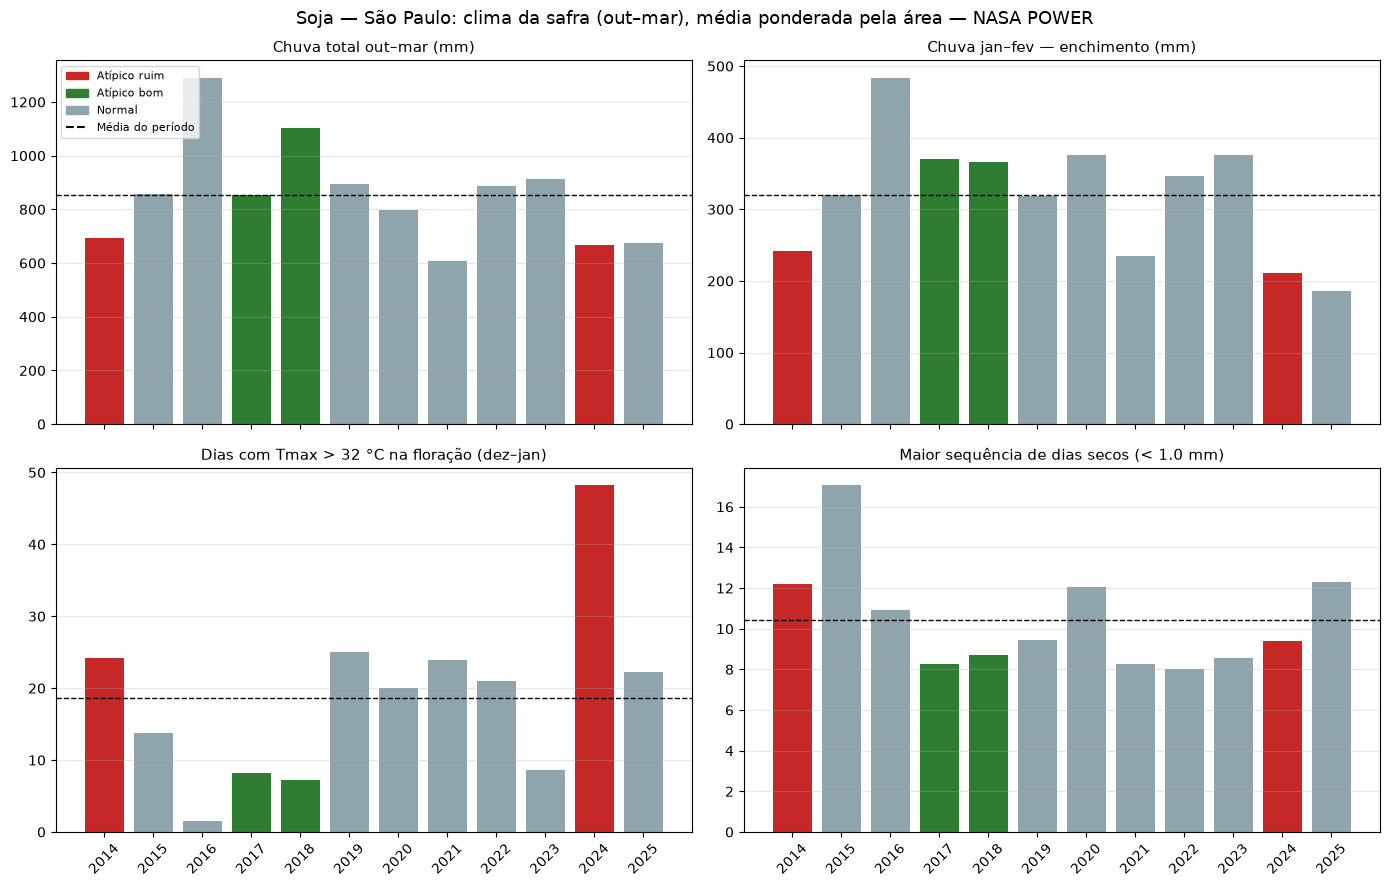

,chuva_out_mar_mm,chuva_jan_fev_mm,dias_acima_32_floracao,max_dias_secos_seguidos,tmax_media_jan_fev_c,radiacao_media_out_mar
Ano,,,,,,
2014,691.7,241.8,24.3,12.2,31.7,21.9
2015,857.7,320.7,13.8,17.1,30.1,21.4
2016,1290.9,484.0,1.5,10.9,28.5,19.3
2017,853.5,370.5,8.3,8.3,29.0,21.2
2018,1102.4,365.9,7.3,8.7,28.2,20.4
2019,895.3,318.5,25.1,9.5,31.0,21.4
2020,798.3,375.8,20.0,12.1,30.1,21.3
2021,607.0,235.1,23.9,8.3,31.2,21.7
2022,887.8,345.9,21.0,8.0,30.1,21.6


In [68]:
# Conferencia visual - Média estadual por safra

# Anos atípicos da etapa anterior aparecem destacados: o clima "explica" esses anos?

area_mun_ano = base[["Municipio (Código)", "Ano", "area_colhida_ha"]].assign(
    cod_muni=lambda x: x["Municipio (Código)"].astype(int))
cs = clima_safra[clima_safra["safra_completa"]].merge(
    area_mun_ano[["cod_muni", "Ano", "area_colhida_ha"]], on=["cod_muni", "Ano"], how="inner")

# média ponderada: soma(indicador x área) / soma(área), por safra
pond = cs[indicadores].mul(cs["area_colhida_ha"], axis=0).assign(Ano=cs["Ano"])
clima_estado = (pond.groupby("Ano")[indicadores].sum()
                .div(cs.groupby("Ano")["area_colhida_ha"].sum(), axis=0))

tipo = anos_atip["tipo_ano"] if "anos_atip" in globals() else pd.Series("Normal", index=clima_estado.index)
CORES_TIPO = {"Atípico ruim": "#C62828", "Atípico bom": "#2E7D32", "Normal": "#90A4AE"}
cores = [CORES_TIPO.get(tipo.get(a, "Normal"), "#90A4AE") for a in clima_estado.index]

paineis = [
    ("chuva_out_mar_mm", "Chuva total out–mar (mm)"),
    ("chuva_jan_fev_mm", "Chuva jan–fev — enchimento (mm)"),
    ("dias_acima_32_floracao", f"Dias com Tmax > {LIMIAR_CALOR} °C na floração (dez–jan)"),
    ("max_dias_secos_seguidos", f"Maior sequência de dias secos (< {LIMIAR_DIA_SECO} mm)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (col, titulo) in zip(axes.flat, paineis):
    ax.bar(clima_estado.index, clima_estado[col], color=cores)
    ax.axhline(clima_estado[col].mean(), color="black", ls="--", lw=1, label="Média do período")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(clima_estado.index)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3, axis="y")
axes[0, 0].legend(
    handles=[Patch(color=c, label=t) for t, c in CORES_TIPO.items()]
    + [plt.Line2D([], [], color="black", ls="--", label="Média do período")],
    fontsize=8, loc="upper left")
fig.suptitle("Soja — São Paulo: clima da safra (out–mar), média ponderada pela área — NASA POWER",
             fontsize=13)
plt.tight_layout()
plt.show()

display(clima_estado.round(1))

In [69]:
# Desvio de produtividade + clima (município x safra) 


base_modelo = desvios_mun_ano.merge(
    clima_safra[clima_safra["safra_completa"]], on=["cod_muni", "Ano"], how="inner")

print(f"base_modelo: {len(base_modelo)} linhas | {base_modelo['cod_muni'].nunique()} municípios | "
      f"safras {base_modelo['Ano'].min()}–{base_modelo['Ano'].max()}")

# Primeira leitura: correlação de cada indicador com o desvio de produtividade
corr = (base_modelo[[f"{c}_anom" for c in indicadores] + ["desvio_mun_pct"]]
        .corr(method="spearman")["desvio_mun_pct"].drop("desvio_mun_pct")
        .sort_values())
print("\nCorrelação (Spearman) entre anomalia climática e desvio de produtividade:")
print(corr.round(2).to_string())

clima_safra.to_csv("clima_safra_soja_sp.csv", index=False)
base_modelo.to_csv("base_modelo_soja_sp.csv", index=False)

base_modelo: 3715 linhas | 330 municípios | safras 2014–2025

Correlação (Spearman) entre anomalia climática e desvio de produtividade:
tmax_media_jan_fev_c_anom      -0.34
dias_acima_32_floracao_anom    -0.33
radiacao_media_out_mar_anom    -0.24
max_dias_secos_seguidos_anom   -0.13
chuva_out_mar_mm_anom           0.24
chuva_jan_fev_mm_anom           0.27


In [70]:
#  Montagem: uma linha por município x ano

MIN_ANOS_HIST = 2               # mínimo de anos com colheita na janela de 3 para a média valer
AREA_DO_PROPRIO_ANO = False     # True = usa a área colhida do mesmo ano (risco de vazamento)
REMOVER_SERIES_SUSPEITAS = True # séries com valores repetidos ano a ano (etapa de variabilidade)

painel = base[["Municipio (Código)", "Municipio", "Ano", "rendimento_kg_ha", "area_colhida_ha"]].copy()
painel["cod_muni"] = painel["Municipio (Código)"].astype(int)

# Grade completa município x ano (inclusive anos sem colheita), para o "ano anterior" ser o ano-calendário
anos_todos = range(int(painel["Ano"].min()), int(painel["Ano"].max()) + 1)
idx = pd.MultiIndex.from_product([painel["cod_muni"].unique(), anos_todos], names=["cod_muni", "Ano"])
grade = painel.set_index(["cod_muni", "Ano"])[["rendimento_kg_ha", "area_colhida_ha"]].reindex(idx)

por_mun = grade.groupby(level="cod_muni")
grade["rend_hist3_kg_ha"] = por_mun["rendimento_kg_ha"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=MIN_ANOS_HIST).mean())
grade["n_anos_hist3"] = por_mun["rendimento_kg_ha"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=0).count())
grade["area_ano_anterior_ha"] = por_mun["area_colhida_ha"].shift(1)

grade = grade.reset_index()
grade = grade[grade["rendimento_kg_ha"].notna()]       # só anos em que houve colheita (o alvo existe)

# Localização
nomes = painel.drop_duplicates("cod_muni").set_index("cod_muni")["Municipio"]
grade["Municipio"] = grade["cod_muni"].map(nomes)
grade = grade.merge(mun_clima[["cod_muni", "lat", "lon"]], on="cod_muni", how="left")
grade["area_feature_ha"] = grade["area_colhida_ha"] if AREA_DO_PROPRIO_ANO else grade["area_ano_anterior_ha"]

# Clima (Fase 3) — valores brutos da safra; lat/lon já dão ao modelo o "normal" de cada lugar
FEATURES_CLIMA = ["chuva_out_mar_mm", "chuva_jan_fev_mm", "dias_acima_32_floracao",
                  "max_dias_secos_seguidos", "tmax_media_jan_fev_c", "tmin_media_out_mar_c",
                  "radiacao_media_out_mar"]
grade = grade.merge(clima_safra.loc[clima_safra["safra_completa"], ["cod_muni", "Ano"] + FEATURES_CLIMA],
                    on=["cod_muni", "Ano"], how="left")

# Qualidade da série
grade = grade.merge(var_mun[["cod_muni", "serie_suspeita"]], on="cod_muni", how="left")
grade["serie_suspeita"] = grade["serie_suspeita"].fillna(False).astype(bool)

# Alvo
grade["rend_sc_ha"] = grade["rendimento_kg_ha"] / 60

COLUNAS = {
    "Identificação": ["cod_muni", "Municipio"],
    "Alvo": ["rendimento_kg_ha", "rend_sc_ha"],
    "Tendência": ["Ano"],
    "Histórico": ["rend_hist3_kg_ha", "n_anos_hist3"],
    "Localização": ["lat", "lon", "area_feature_ha"],
    "Clima": FEATURES_CLIMA,
    "Controle": ["area_colhida_ha", "serie_suspeita"],
}
base_modelagem = grade[[c for grupo in COLUNAS.values() for c in grupo]].sort_values(["cod_muni", "Ano"])

FEATURES = (COLUNAS["Tendência"] + ["rend_hist3_kg_ha"] + COLUNAS["Localização"] + FEATURES_CLIMA)
ALVO = "rendimento_kg_ha"

print(f"Linhas montadas (município x ano com colheita): {len(base_modelagem)}")

Linhas montadas (município x ano com colheita): 5024


In [71]:
#Teste de vazamento: refaz o histórico "na mão" para alguns municípios e compara


amostra = base_modelagem.dropna(subset=["rend_hist3_kg_ha"]).sample(
    min(200, base_modelagem["rend_hist3_kg_ha"].notna().sum()), random_state=42)
serie = painel.set_index(["cod_muni", "Ano"])["rendimento_kg_ha"]
for r in amostra.itertuples():
    anteriores = [serie.get((r.cod_muni, a)) for a in (r.Ano - 1, r.Ano - 2, r.Ano - 3)]
    anteriores = [v for v in anteriores if v is not None and not pd.isna(v)]
    assert np.isclose(np.mean(anteriores), r.rend_hist3_kg_ha), f"Histórico errado: {r.cod_muni} {r.Ano}"
print(f"OK: histórico confere em {len(amostra)} linhas sorteadas (usa apenas os 3 anos anteriores)")

# 2.2 Faltantes por coluna (antes dos filtros)
falt = base_modelagem[FEATURES + [ALVO]].isna().mean().mul(100).round(1)
print("\n% de faltantes por coluna:")
print(falt[falt > 0].to_string() if (falt > 0).any() else "nenhum")

# 2.3 Filtros e motivo de cada exclusão
f = base_modelagem.copy()
exclusoes = {}
exclusoes["sem histórico suficiente (início da série)"] = f["rend_hist3_kg_ha"].isna().sum()
f = f[f["rend_hist3_kg_ha"].notna()]
if REMOVER_SERIES_SUSPEITAS:
    exclusoes["série suspeita (valores repetidos)"] = f["serie_suspeita"].sum()
    f = f[~f["serie_suspeita"]]
sem_clima = f[FEATURES_CLIMA + ["lat", "lon", "area_feature_ha"]].isna().any(axis=1)
exclusoes["sem clima / localização / área anterior"] = sem_clima.sum()
f = f[~sem_clima]

base_final = f.reset_index(drop=True)

print("\nExclusões:")
for motivo, qtd in exclusoes.items():
    print(f"  - {motivo:<45} {qtd:>6}")
print(f"\nBASE FINAL: {len(base_final)} linhas | {base_final['cod_muni'].nunique()} municípios | "
      f"anos {base_final['Ano'].min()}–{base_final['Ano'].max()} | {len(FEATURES)} features")
print(base_final.groupby("Ano").size().rename("linhas por ano").to_string())

display(base_final.head())
base_final.to_csv("base_modelagem_soja_sp.csv", index=False)

OK: histórico confere em 200 linhas sorteadas (usa apenas os 3 anos anteriores)

% de faltantes por coluna:
rend_hist3_kg_ha    21.6
area_feature_ha     12.3

Exclusões:
  - sem histórico suficiente (início da série)      1084
  - série suspeita (valores repetidos)               757
  - sem clima / localização / área anterior           13

BASE FINAL: 3170 linhas | 378 municípios | anos 2016–2025 | 12 features
Ano
2016    226
2017    251
2018    290
2019    314
2020    323
2021    333
2022    350
2023    360
2024    366
2025    357


,cod_muni,Municipio,rendimento_kg_ha,rend_sc_ha,Ano,rend_hist3_kg_ha,n_anos_hist3,lat,lon,area_feature_ha,chuva_out_mar_mm,chuva_jan_fev_mm,dias_acima_32_floracao,max_dias_secos_seguidos,tmax_media_jan_fev_c,tmin_media_out_mar_c,radiacao_media_out_mar,area_colhida_ha,serie_suspeita
0,3500105,Adamantina - SP,2400.0,40.000000,2018,2100.0,2.0,-21.5766,-51.0568,300.0,1171.02,360.36,6.0,11,29.240678,21.249286,21.453681,300.0,False
1,3500105,Adamantina - SP,1800.0,30.000000,2019,2200.0,3.0,-21.5766,-51.0568,300.0,812.45,278.63,43.0,13,32.762881,22.066209,22.179066,400.0,False
2,3500105,Adamantina - SP,1800.0,30.000000,2020,2200.0,3.0,-21.5766,-51.0568,400.0,790.00,384.58,27.0,12,31.102833,22.067158,22.211257,500.0,False
3,3500105,Adamantina - SP,3000.0,50.000000,2021,2000.0,3.0,-21.5766,-51.0568,500.0,525.99,204.64,41.0,12,33.318136,22.301429,22.514835,450.0,False
4,3500105,Adamantina - SP,2068.0,34.466667,2022,2200.0,3.0,-21.5766,-51.0568,450.0,744.20,340.07,41.0,9,31.762712,21.677582,22.355000,500.0,False


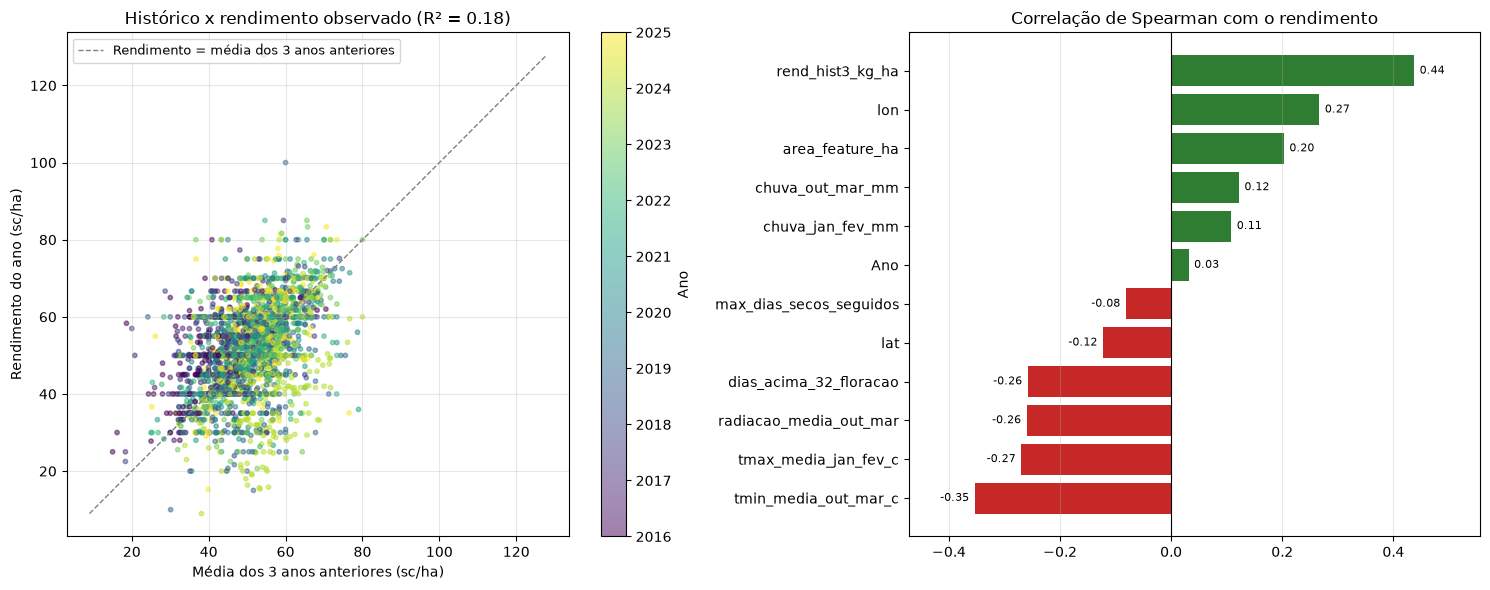

,count,mean,std,min,25%,50%,75%,max
Ano,3170.0,2020.9,2.8,2016.0,2019.0,2021.0,2023.0,2025.0
rend_hist3_kg_ha,3170.0,3012.8,534.9,900.0,2660.0,3000.0,3354.8,4800.0
lat,3170.0,-21.8,1.0,-24.1,-22.6,-21.8,-20.9,-19.9
lon,3170.0,-49.2,1.4,-52.8,-50.2,-49.4,-48.2,-45.1
area_feature_ha,3170.0,3125.3,6939.9,1.0,300.0,800.0,2500.0,82000.0
chuva_out_mar_mm,3170.0,838.2,196.6,385.7,694.3,831.5,951.3,1532.8
chuva_jan_fev_mm,3170.0,318.6,104.1,114.9,224.4,329.9,395.5,607.9
dias_acima_32_floracao,3170.0,21.6,17.4,0.0,7.0,17.0,35.0,62.0
max_dias_secos_seguidos,3170.0,9.8,2.9,5.0,8.0,9.0,11.0,21.0
tmax_media_jan_fev_c,3170.0,30.6,2.1,26.0,29.0,30.4,32.2,36.8


In [72]:
#  Visão geral das features

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.1, 1]})

# 3.1 O histórico sozinho já explica quanto? (é a "régua" que o modelo precisa superar)
x_h, y_r = base_final["rend_hist3_kg_ha"] / 60, base_final["rend_sc_ha"]
sc = ax1.scatter(x_h, y_r,
                 c=base_final["Ano"], cmap="viridis", s=10, alpha=0.5)
lim = [min(x_h.min(), y_r.min()), max(x_h.max(), y_r.max())]
ax1.plot(lim, lim, "--", color="gray", lw=1, label="Rendimento = média dos 3 anos anteriores")
r2_hist = base_final["rend_hist3_kg_ha"].corr(base_final["rendimento_kg_ha"]) ** 2
ax1.set_xlabel("Média dos 3 anos anteriores (sc/ha)")
ax1.set_ylabel("Rendimento do ano (sc/ha)")
ax1.set_title(f"Histórico x rendimento observado (R² = {r2_hist:.2f})")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.3)
fig.colorbar(sc, ax=ax1, label="Ano")

# 3.2 Correlação (Spearman) de cada feature com o alvo
corr_alvo = (base_final[FEATURES + [ALVO]].corr(method="spearman")[ALVO]
             .drop(ALVO).sort_values())
cores_c = np.where(corr_alvo >= 0, "#2E7D32", "#C62828")
ax2.barh(corr_alvo.index, corr_alvo.values, color=cores_c)
ax2.axvline(0, color="black", lw=0.8)
for i, v in enumerate(corr_alvo.values):
    ax2.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=8)
ax2.margins(x=0.15)
ax2.set_title("Correlação de Spearman com o rendimento")
ax2.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Resumo estatístico por grupo
display(base_final[FEATURES + [ALVO]].describe().T.round(1))